In [29]:
import sys
sys.path.append("train")
sys.path.append("evaluation")
sys.path.append("ensemble")
sys.path.append("pipeline")

import pandas as pd
import joblib
import pandas as pd
from minisom import MiniSom
from sklearn.preprocessing import MinMaxScaler
import importlib
from tqdm import tqdm

import data_main
importlib.reload(data_main)
from data_main import run_full_pipeline, print_final_stats

import feature_selection
importlib.reload(feature_selection)
from feature_selection import grid_search_features_som 

import som_model
importlib.reload(som_model)
from som_model import train_som_model, grid_search_som, evaluate_cluster_stability

import som_strategy_runner
importlib.reload(som_strategy_runner)
from som_strategy_runner import get_datasets_from_df, generate_cluster_signals, process_and_signal, plot_umatrix, plot_density_map, plot_signals

import voting_strategies
importlib.reload(voting_strategies)
from voting_strategies import majority_vote, weighted_vote, unanimous_vote, aggressive_vote, probabilistic_vote

import run_ensemble_strategies
importlib.reload(run_ensemble_strategies)
from run_ensemble_strategies import run_majority_ensemble, run_weighted_ensemble, run_unanimous_ensemble, run_aggressive_ensemble, run_probabilistic_ensemble, plot_result

import strategy_eval
importlib.reload(strategy_eval)
from strategy_eval import simulate_strategy, evaluate_strategy, compute_fear_greed_index, compare_strategy, compare_trading_strategies

from config import DATA_DIR
import matplotlib.pyplot as plt

## data collection and preprocessing

In [7]:
df_merged = run_full_pipeline()

Dataset saved to data/merged.csv

Merged Dataset Info
----------------------------------------
Columns: ['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'RSI', 'MACD', 'CCI', 'WILLR', 'SMA_50', 'SMA_200', 'EMA_50', 'EMA_200', 'Bollinger_Upper', 'Bollinger_Lower', 'ATR', 'OBV', 'CMF', 'Momentum', 'ROC', 'UO', 'avg_sentiment_score', 'avg_sentiment_label_score', 'pos_count', 'neut_count', 'neg_count', 'total', 'pct_positive', 'pct_neutral', 'pct_negative']
                            count          mean           std           min  \
Close                      3310.0  1.523792e+04  1.635578e+04  1.781030e+02   
High                       3310.0  1.558247e+04  1.674636e+04  2.117310e+02   
Low                        3310.0  1.484392e+04  1.591502e+04  1.715100e+02   
Open                       3310.0  1.522733e+04  1.635518e+04  1.768970e+02   
Volume                     3310.0  1.716320e+10  1.913655e+10  7.860650e+06   
RSI                        3296.0  5.362075e+01  1.413202e+01  9.9

In [2]:
df = pd.read_csv(f"{DATA_DIR}/merged.csv", parse_dates=["Date"])
df.set_index("Date", inplace=True)

In [3]:
df.head()

,Close,High,Low,Open,Volume,RSI,MACD,CCI,WILLR,SMA_50,...,total,pct_positive,pct_neutral,pct_negative,sentiment_score_combined,sentiment_polarization,log_total_sentiment,z_sentiment_score_combined,z_sentiment_polarization,z_log_total_sentiment
Date,,,,,,,,,,,,,,,,,,,,,
2015-01-01,314.248993,320.434998,314.002991,320.434998,8036550,NaN,NaN,NaN,NaN,NaN,...,1.0,0.000000,0.000000,1.000000,0.344592,-1.0,0.693147,-1.142313,-3.297529,-1.320819
2015-01-02,315.032013,315.838989,313.565002,314.079010,7860650,NaN,NaN,NaN,NaN,NaN,...,4.0,0.250000,0.500000,0.250000,0.698077,0.0,1.609438,0.437163,-0.081158,-0.648885
2015-01-03,281.082001,315.149994,281.082001,314.846008,33054400,NaN,NaN,NaN,NaN,NaN,...,1.0,0.000000,1.000000,0.000000,0.699959,0.0,0.693147,0.445574,-0.081158,-1.320819
2015-01-04,264.195007,287.230011,257.612000,281.145996,55629100,NaN,NaN,NaN,NaN,NaN,...,1.0,0.000000,0.000000,1.000000,0.171777,-1.0,0.693147,-1.914505,-3.297529,-1.320819
2015-01-05,274.473999,278.341003,265.084015,265.084015,43962800,NaN,NaN,NaN,NaN,NaN,...,11.0,0.090909,0.818182,0.090909,0.661607,0.0,2.484907,0.274204,-0.081158,-0.006887


In [23]:
df.columns

Index(['Close', 'High', 'Low', 'Open', 'Volume', 'RSI', 'MACD', 'CCI', 'WILLR',
       'SMA_50', 'SMA_200', 'EMA_50', 'EMA_200', 'Bollinger_Upper',
       'Bollinger_Lower', 'ATR', 'OBV', 'CMF', 'Momentum', 'ROC', 'UO',
       'avg_sentiment_score', 'avg_sentiment_label_score', 'pos_count',
       'neut_count', 'neg_count', 'total', 'pct_positive', 'pct_neutral',
       'pct_negative', 'sentiment_score_combined', 'sentiment_polarization',
       'log_total_sentiment', 'z_sentiment_score_combined',
       'z_sentiment_polarization', 'z_log_total_sentiment'],
      dtype='object')

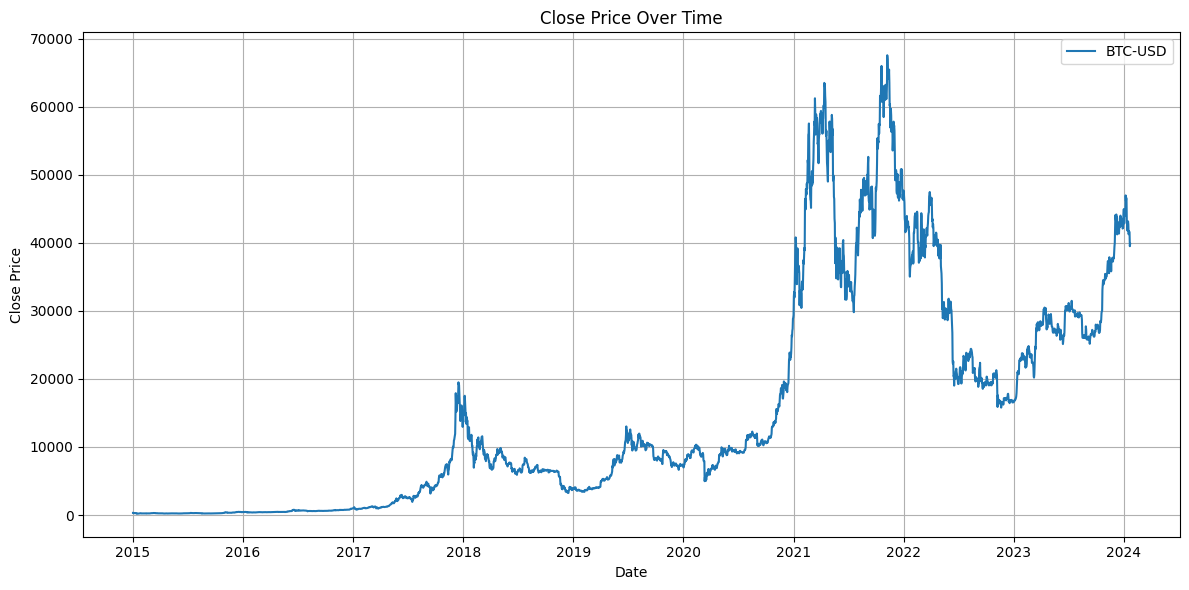

In [56]:
df = df.sort_index()
if not isinstance(df.index, pd.DatetimeIndex):
    df.index = pd.to_datetime(df.index)

plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Close'], label='BTC-USD')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.title('Close Price Over Time')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [3]:
train_val_df, train_df, val_df, test_df = get_datasets_from_df(df)

In [4]:
train_val_df.describe()

,Close,High,Low,Open,Volume,RSI,MACD,CCI,WILLR,SMA_50,...,total,pct_positive,pct_neutral,pct_negative,sentiment_score_combined,sentiment_polarization,log_total_sentiment,z_sentiment_score_combined,z_sentiment_polarization,z_log_total_sentiment
count,2557.000000,2557.000000,2557.000000,2557.000000,2.557000e+03,2543.000000,2532.000000,2544.000000,2544.000000,2508.000000,...,2557.000000,2557.000000,2557.000000,2557.000000,2557.000000,2557.000000,2557.000000,2557.000000,2557.000000,2557.000000
mean,11191.218051,11481.716685,10840.109565,11175.098322,1.506913e+10,54.519894,138.963988,22.642964,-43.102726,10918.246272,...,18.838874,0.235125,0.434397,0.202985,0.584173,0.032140,2.241947,-0.071795,0.022216,-0.185054
std,15892.528466,16321.869234,15383.233513,15883.370442,2.026177e+10,14.090289,947.973670,110.367438,29.686531,15356.397130,...,23.141698,0.219377,0.282852,0.210911,0.247701,0.323636,1.349929,1.106802,1.040935,0.989929
min,178.102997,211.731003,171.509995,176.897003,7.860650e+06,9.920239,-5053.274080,-438.238899,-100.000000,232.261620,...,0.000000,0.000000,0.000000,0.000000,0.000000,-1.000000,0.000000,-2.682055,-3.297529,-1.829117
25%,664.551025,673.276978,653.697998,663.781006,9.706440e+07,44.441310,-38.539758,-62.023583,-68.805914,662.758473,...,2.000000,0.000000,0.266667,0.000000,0.570523,-0.068966,1.098612,-0.132784,-0.302976,-1.023484
50%,6416.314941,6535.410156,6316.879883,6413.629883,5.302482e+09,53.612912,7.870209,30.310964,-40.810914,6621.637314,...,11.000000,0.222222,0.461538,0.178571,0.661742,0.000000,2.484907,0.274807,-0.081158,-0.006887
75%,10366.700195,10598.940430,10132.186523,10358.722656,2.512725e+10,63.933065,218.078902,107.566384,-15.096219,10427.073506,...,26.000000,0.344086,0.600000,0.300000,0.709726,0.171429,3.295837,0.489218,0.470220,0.587784
max,67566.828125,68789.625000,66382.062500,67549.734375,3.509679e+11,94.302215,5273.808690,396.358432,0.000000,60801.771016,...,190.000000,1.000000,1.000000,1.000000,1.000000,1.000000,5.252273,1.786248,3.135214,2.022478


In [5]:
test_df.describe()

,Close,High,Low,Open,Volume,RSI,MACD,CCI,WILLR,SMA_50,...,total,pct_positive,pct_neutral,pct_negative,sentiment_score_combined,sentiment_polarization,log_total_sentiment,z_sentiment_score_combined,z_sentiment_polarization,z_log_total_sentiment
count,753.000000,753.000000,753.000000,753.000000,7.530000e+02,753.000000,753.000000,753.000000,753.000000,753.000000,...,753.000000,753.000000,753.000000,753.000000,753.000000,753.000000,753.000000,753.000000,753.000000,753.000000
mean,28979.521884,29507.601303,28439.854675,28987.694311,2.427415e+10,50.584213,-69.714340,2.626918,-50.252749,29210.453196,...,41.239044,0.277323,0.444476,0.275545,0.654802,0.001777,3.351218,0.243798,-0.075441,0.628397
std,8595.283719,8785.110153,8401.995351,8608.889453,1.226657e+10,13.856184,1032.917624,114.296484,29.953026,8689.327321,...,31.892543,0.145231,0.153651,0.158859,0.089749,0.262220,1.019490,0.401027,0.843397,0.747612
min,15787.284180,16253.047852,15599.046875,15782.300781,5.331173e+09,19.010498,-2966.248122,-380.907690,-100.000000,16788.621816,...,0.000000,0.000000,0.000000,0.000000,0.000000,-1.000000,0.000000,-2.682055,-3.297529,-1.829117
25%,21680.539062,22060.994141,21103.197266,21678.542969,1.553404e+10,40.903175,-581.656992,-82.442901,-77.961927,22033.360859,...,13.000000,0.190476,0.361111,0.176471,0.613791,-0.128205,2.639057,0.060550,-0.493513,0.106155
50%,27530.785156,28044.759766,27069.207031,27514.873047,2.276545e+10,48.442447,-86.203805,-6.118756,-51.041368,27632.185273,...,38.000000,0.267442,0.438596,0.258065,0.659581,0.000000,3.663562,0.265153,-0.081158,0.857444
75%,36852.121094,37493.800781,35813.812500,36841.878906,3.044809e+10,59.671529,587.019538,89.433957,-21.726077,36885.767969,...,59.000000,0.355263,0.517857,0.352941,0.701184,0.156863,4.094345,0.451045,0.423371,1.173346
max,47686.812500,48969.371094,47100.437500,47680.925781,1.189925e+11,89.351771,2152.616396,334.070466,0.000000,52604.358828,...,215.000000,1.000000,1.000000,1.000000,0.999983,1.000000,5.375278,1.786173,3.135214,2.112680


In [5]:
print(train_df.shape)
print(val_df.shape)

(1827, 36)
(730, 36)


In [ ]:
train_start = train_df.index.min()
train_end = train_df.index.max()

val_start = val_df.index.min()
val_end = val_df.index.max()

test_start = test_df.index.min()
test_end = test_df.index.max()

print("Train period:", train_start.date(), "to", train_end.date())
print("Validation period:", val_start.date(), "to", val_end.date())
print("Test period:", test_start.date(), "to", test_end.date())

Train period: 2015-01-01 to 2020-01-01
Validation period: 2020-01-02 to 2021-12-31
Test period: 2022-01-01 to 2024-01-23


### Feature subset selection

In [4]:
feature_cols_map = {   
    "technical": [ 'High', 'Low', 'Open', 'Volume', 'RSI', 'MACD', 'CCI', 'WILLR',
       'SMA_50', 'SMA_200', 'EMA_50', 'EMA_200', 'Bollinger_Upper',
       'Bollinger_Lower', 'ATR', 'OBV', 'CMF', 'Momentum', 'ROC', 'UO'],
    "sentiment": [
        'z_sentiment_score_combined',
       'z_sentiment_polarization', 'z_log_total_sentiment'
    ],
    "hybrid": [
        'High', 'Low', 'Open', 'Volume', 'RSI', 'MACD', 'CCI', 'WILLR',
       'SMA_50', 'SMA_200', 'EMA_50', 'EMA_200', 'Bollinger_Upper',
       'Bollinger_Lower', 'ATR', 'OBV', 'CMF', 'Momentum', 'ROC', 'UO',
       'z_sentiment_score_combined',
       'z_sentiment_polarization', 'z_log_total_sentiment' 
    ]
}

In [36]:
som_types = ["technical"]
best_features_map = {}
full_results_map = {}

for som_type in som_types:
    full_feature_list = feature_cols_map[som_type]

    results_df, best_features = grid_search_features_som(
        model_name=som_type,
        train_df=train_df,
        train_val=val_df,
        full_feature_list=full_feature_list,
        feature_subset_size=6,
        num_trials=100 
    )

    best_features_map[som_type] = best_features
    full_results_map[som_type] = results_df

    print(f"\nBest features for {som_type}: {best_features}")
    print(f"Top Sharpe: {results_df.iloc[0]['Sharpe Ratio']:.2f}")


Feature search for technical: 100%|██████████| 100/100 [42:52<00:00, 25.72s/it]


Best features for technical: ['Low', 'ROC', 'OBV', 'CMF', 'MACD', 'High']
Top Sharpe: 2.25


In [37]:
full_results_map

{'technical':       Model Name  SOM Size  Sigma  Learning Rate  Iterations  \
 0      technical  (10, 10)    0.5            0.3        1500   
 1      technical    (5, 5)    0.5            0.5        1500   
 2      technical    (5, 5)    1.5            0.3         500   
 3      technical  (10, 10)    1.0            0.1        1500   
 4      technical  (15, 15)    1.0            0.3        1500   
 ...          ...       ...    ...            ...         ...   
 10795  technical    (5, 5)    1.5            0.1        1500   
 10796  technical    (5, 5)    0.5            0.5        1000   
 10797  technical    (5, 5)    0.5            0.1        1000   
 10798  technical  (10, 10)    0.5            0.1         500   
 10799  technical  (10, 10)    1.0            0.3         500   
 
        Cumulative Return  Sharpe Ratio  Max Drawdown  \
 0               2.774891      2.247400      0.096909   
 1               2.611402      2.232512      0.088346   
 2               3.270684      2.2

In [49]:
technical_sorted = full_results_map['technical'].sort_values(by='Cumulative Return', ascending=False)

In [50]:
technical_sorted.head(5)

,Model Name,SOM Size,Sigma,Learning Rate,Iterations,Cumulative Return,Sharpe Ratio,Max Drawdown,Features
54,technical,"(20, 20)",1.5,0.5,500,3.864525,1.829514,0.295129,"[Open, CCI, EMA_50, ROC, OBV, CMF]"
141,technical,"(10, 10)",1.5,0.5,500,3.379528,1.610145,0.295129,"[Open, Bollinger_Upper, ROC, ATR, SMA_50, OBV]"
149,technical,"(15, 15)",1.5,0.1,1000,3.346924,1.596603,0.295129,"[Volume, Momentum, Open, Bollinger_Lower, Low,..."
148,technical,"(10, 10)",1.5,0.5,500,3.346924,1.596603,0.295129,"[Bollinger_Lower, Bollinger_Upper, High, ROC, ..."
166,technical,"(15, 15)",1.5,0.1,1500,3.315265,1.558509,0.295129,"[OBV, Bollinger_Lower, CCI, Volume, CMF, EMA_50]"


In [6]:
best_features_map = {'technical':  ['Open', 'CCI', 'EMA_50', 'ROC', 'OBV', 'CMF'], 
 'sentiment': ['z_sentiment_score_combined', 'z_sentiment_polarization', 'z_log_total_sentiment'],
 'hybrid': ['Open', 'CCI', 'EMA_50', 'ROC', 'OBV', 'CMF', 'z_sentiment_score_combined', 'z_sentiment_polarization', 'z_log_total_sentiment'] }    #['MACD', 'Momentum', 'Open', 'z_log_total_sentiment', 'High', 'Bollinger_Lower']

### Grid search

Execute the grid search for each SOM type

In [5]:
som_types = ["technical", "sentiment", "hybrid"]
all_results = []

for som_type in som_types:
    result_df = grid_search_som(
        model_name=som_type,
        train_df=train_df,
        val_df=val_df,
        cols=best_features_map[som_type], 
        disable=False,
        save_dir="models"
    )
    all_results.append(result_df)


100%|██████████| 108/108 [01:09<00:00,  1.55it/s]


Select the best model for each type

In [6]:
df_all = pd.concat(all_results)

best_models = (
    df_all
    .loc[df_all.groupby("Model Name")["Cumulative Return"].idxmax()]
    .reset_index(drop=True)
    .sort_values(by="Cumulative Return", ascending=False) 
)

best_models

,Model Name,SOM Size,Sigma,Learning Rate,Iterations,Cumulative Return,Sharpe Ratio,Max Drawdown,Features
6,technical,"(20, 20)",1.5,0.5,500,3.864525,1.829514,0.295129,"[Open, CCI, EMA_50, ROC, OBV, CMF]"
4,sentiment,"(10, 10)",0.5,0.3,500,2.648596,1.949727,0.107808,"[z_sentiment_score_combined, z_sentiment_polar..."
2,hybrid,"(15, 15)",1.5,0.1,1000,2.623453,1.354542,0.295129,"[Open, CCI, EMA_50, ROC, OBV, CMF, z_sentiment..."
7,sentiment,"(20, 20)",1.5,0.5,500,1.462086,1.695741,0.052614,"[z_sentiment_score_combined, z_sentiment_polar..."
1,sentiment,"(15, 15)",1.5,0.1,1000,1.215961,0.721100,0.102258,"[z_sentiment_score_combined, z_sentiment_polar..."
0,technical,"(15, 15)",1.5,0.1,1000,1.162690,0.934523,0.047714,"[Open, CCI, EMA_50, ROC, OBV, CMF]"
5,hybrid,"(10, 10)",0.5,0.3,500,1.128636,0.965894,0.032574,"[Open, CCI, EMA_50, ROC, OBV, CMF, z_sentiment..."
8,hybrid,"(20, 20)",1.5,0.5,500,1.025934,0.249170,0.049379,"[Open, CCI, EMA_50, ROC, OBV, CMF, z_sentiment..."
3,technical,"(10, 10)",0.5,0.3,500,1.000000,0.000000,0.000000,"[Open, CCI, EMA_50, ROC, OBV, CMF]"


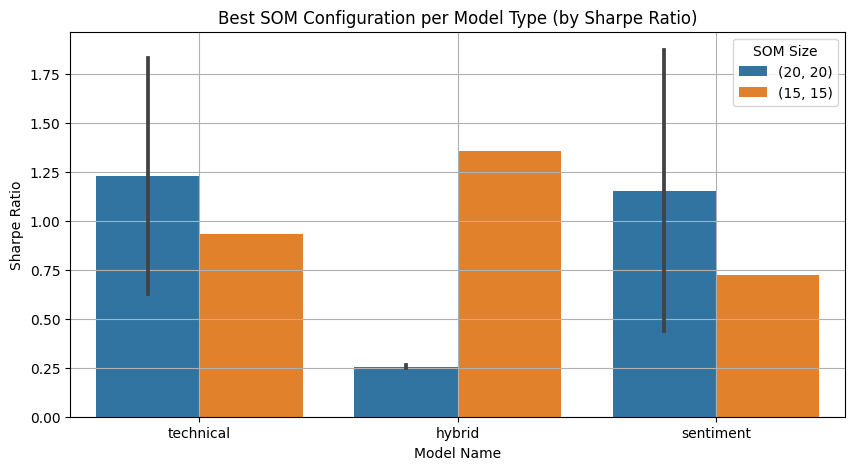

In [121]:
import matplotlib.pyplot as plt
import seaborn as sns

best_models["SOM Size"] = best_models["SOM Size"].astype(str)

plt.figure(figsize=(10, 5))
sns.barplot(data=best_models, x='Model Name', y='Sharpe Ratio', hue='SOM Size')
plt.title('Best SOM Configuration per Model Type (by Sharpe Ratio)')
plt.grid(True)
plt.show()

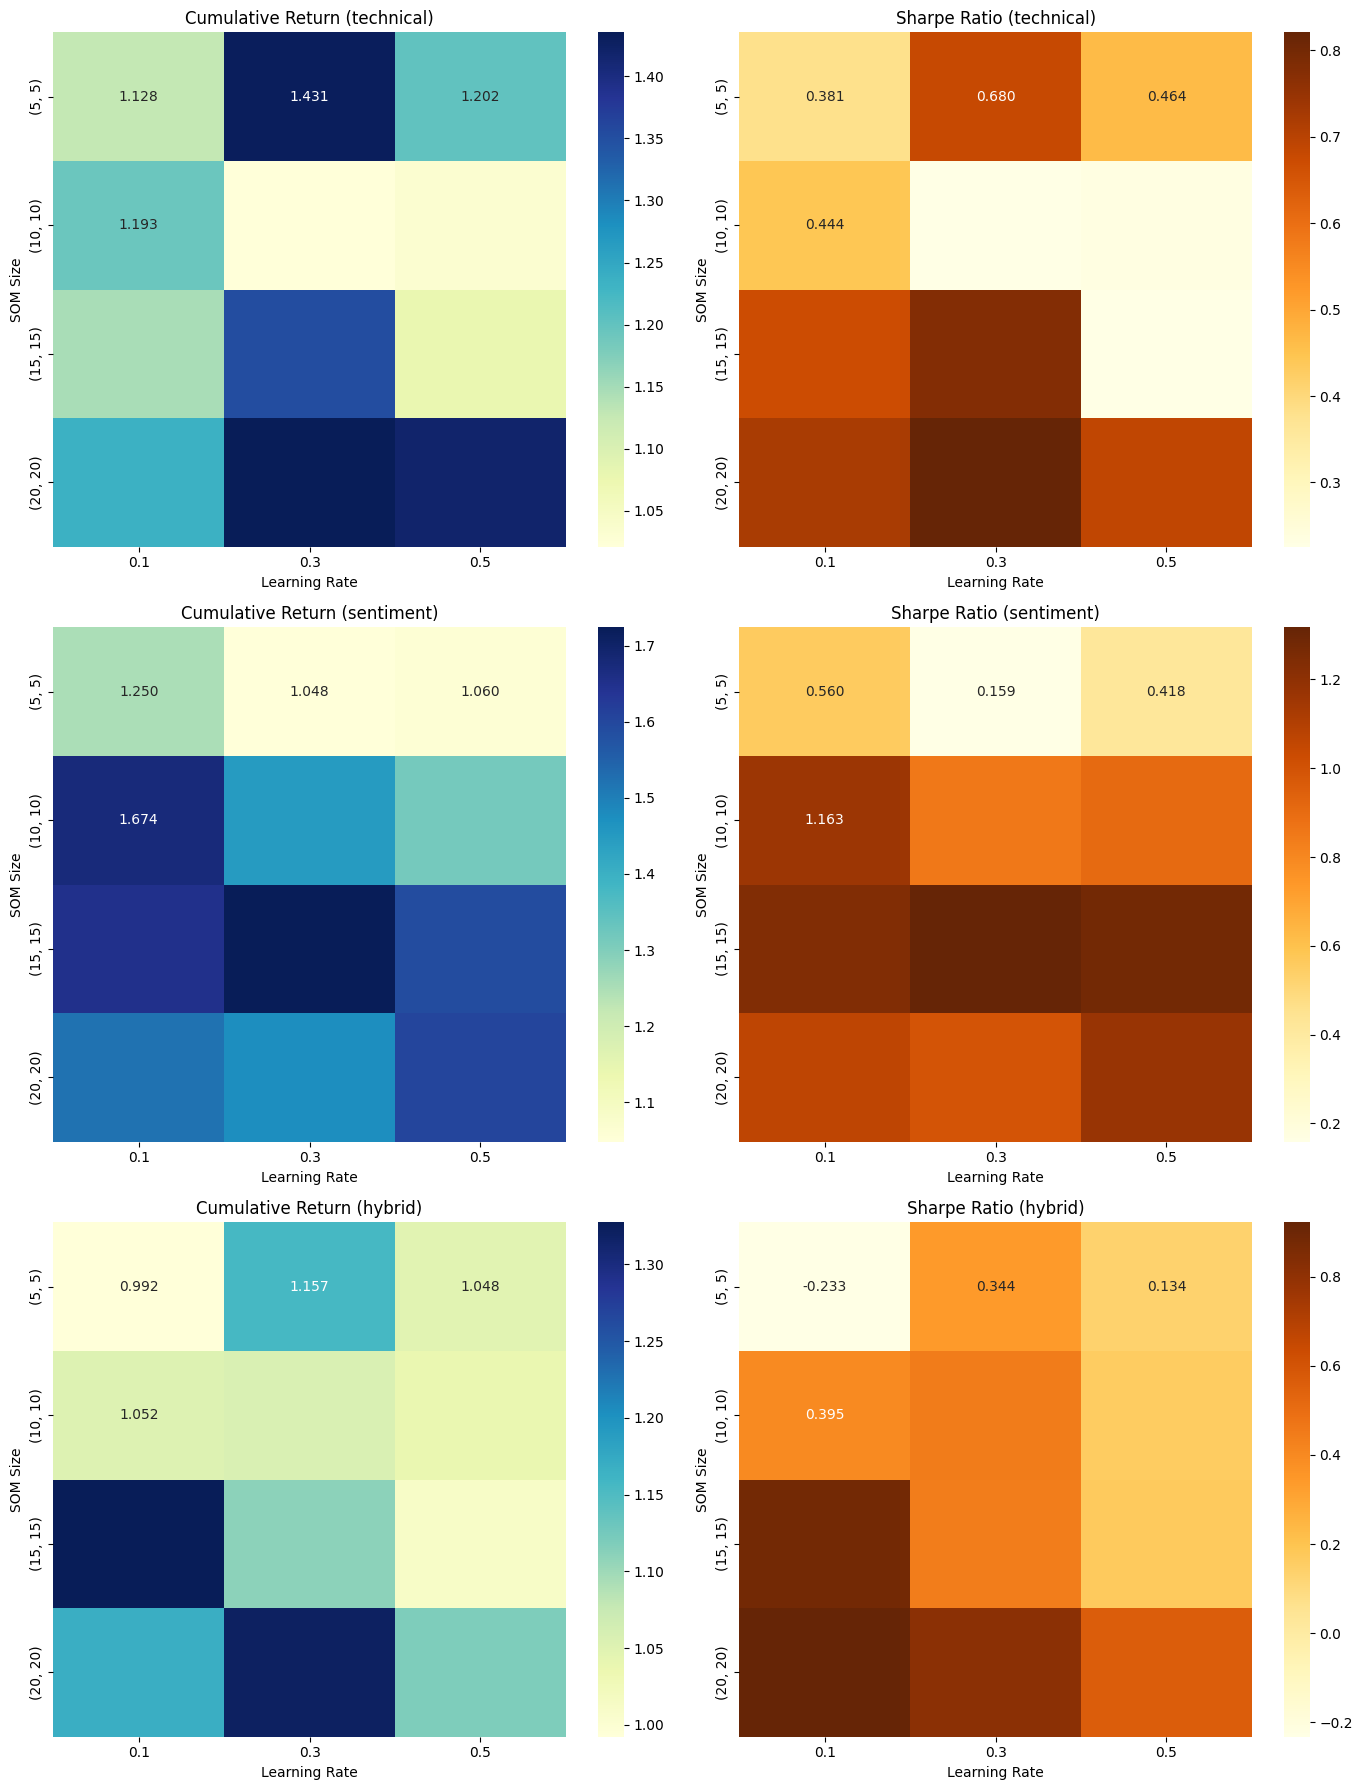

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Setup the figure with as many rows as SOM types, and 2 columns (Return + Sharpe)
fig, axes = plt.subplots(len(som_types), 2, figsize=(14, 6 * len(som_types)))

# Ensure axes is a 2D array even if there's only one SOM type
if len(som_types) == 1:
    axes = [axes]

for i, som_type in enumerate(som_types):
    df_all_plot = df_all[df_all['Model Name'] == som_type]

    # Pivot tables
    pivot_return = df_all_plot.pivot_table(index='SOM Size', columns='Learning Rate', values='Cumulative Return')
    pivot_sharpe = df_all_plot.pivot_table(index='SOM Size', columns='Learning Rate', values='Sharpe Ratio')

    # Heatmap: Cumulative Return
    sns.heatmap(pivot_return, annot=True, fmt=".3f", cmap='YlGnBu', ax=axes[i][0])
    axes[i][0].set_title(f'Cumulative Return ({som_type})')
    axes[i][0].set_ylabel('SOM Size')
    axes[i][0].set_xlabel('Learning Rate')

    # Heatmap: Sharpe Ratio
    sns.heatmap(pivot_sharpe, annot=True, fmt=".3f", cmap='YlOrBr', ax=axes[i][1])
    axes[i][1].set_title(f'Sharpe Ratio ({som_type})')
    axes[i][1].set_ylabel('SOM Size')
    axes[i][1].set_xlabel('Learning Rate')

plt.tight_layout()
plt.show()


## Technical SOM

In [7]:
tech_clusters, som_tech = train_som_model(
    data=train_val_df,
    feature_cols=best_features_map["technical"],
    model_name="technical",
    som_size=(20, 20),
    sigma=1.5,
    learning_rate=0.5,
    num_iter=500,
    save_dir="models",
    to_save=False,
    to_print=True
)

Quantization Error: 0.1432
Topographic Error: 0.8046


In [11]:
stability_score = evaluate_cluster_stability(
    data=train_val_df,
    feature_cols=best_features_map["technical"],
    model_name="technical",
    som_size=(20, 20),
    sigma=1.5,
    learning_rate=0.5,
    num_iter=500,
    save_dir="models",
    to_save=False,
    runs=20)
print(f"Cluster Stability: {stability_score:.4f}")

Cluster Stability: 1.0000


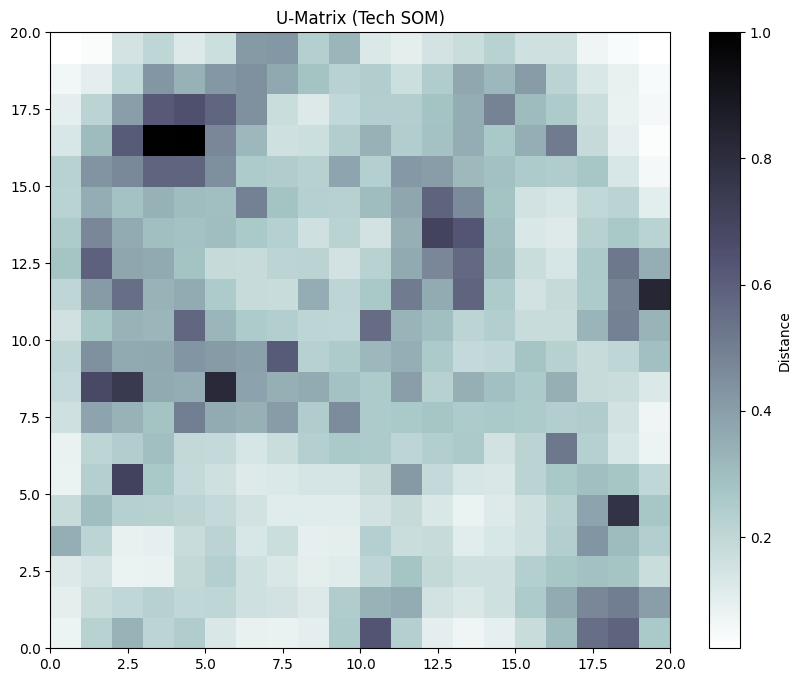

In [12]:
plot_umatrix(som_tech, title="U-Matrix (Tech SOM)")

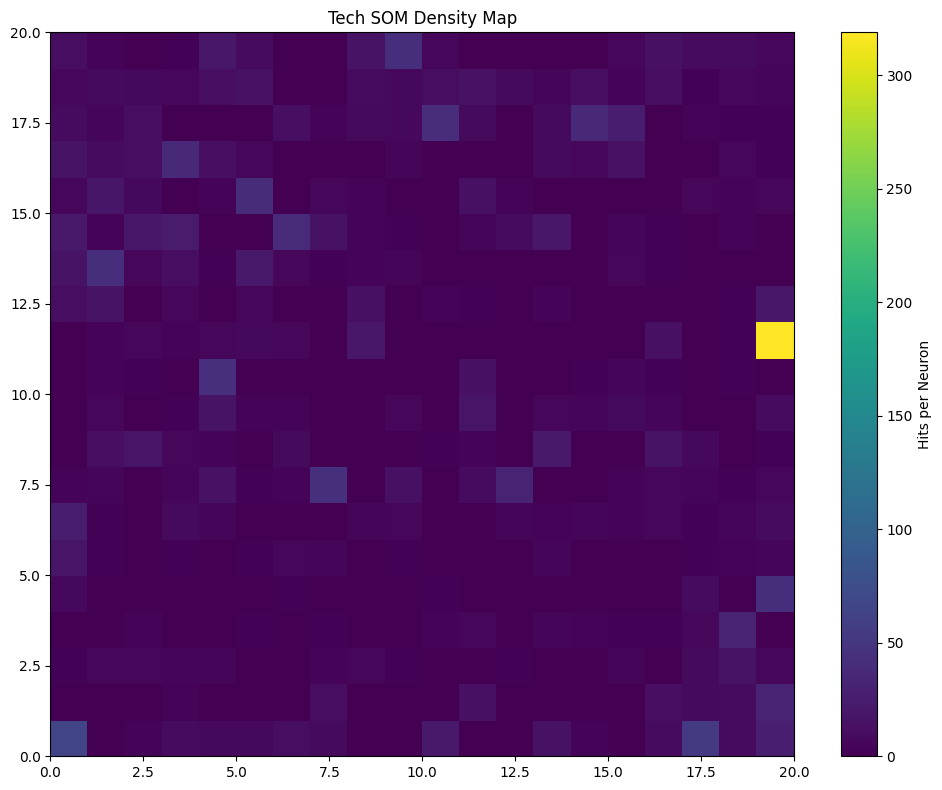

In [30]:
plot_density_map(som_tech, train_val_df[best_features_map["technical"]], title="Tech SOM Density Map")

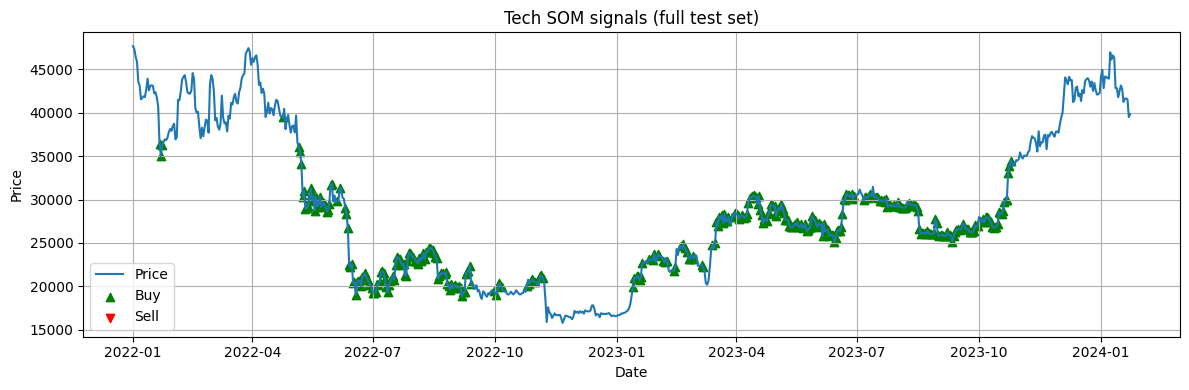

In [36]:
test_df_cut_tech, node_action_tech = process_and_signal(train_val_df, 
    test_df, 
    som_tech, 
    feature_cols=best_features_map["technical"], 
    model_name="tech", 
    save_dir="models"
)

In [24]:
print(test_df_cut_tech['signal'].value_counts())

buy     379
hold    303
Name: signal, dtype: int64


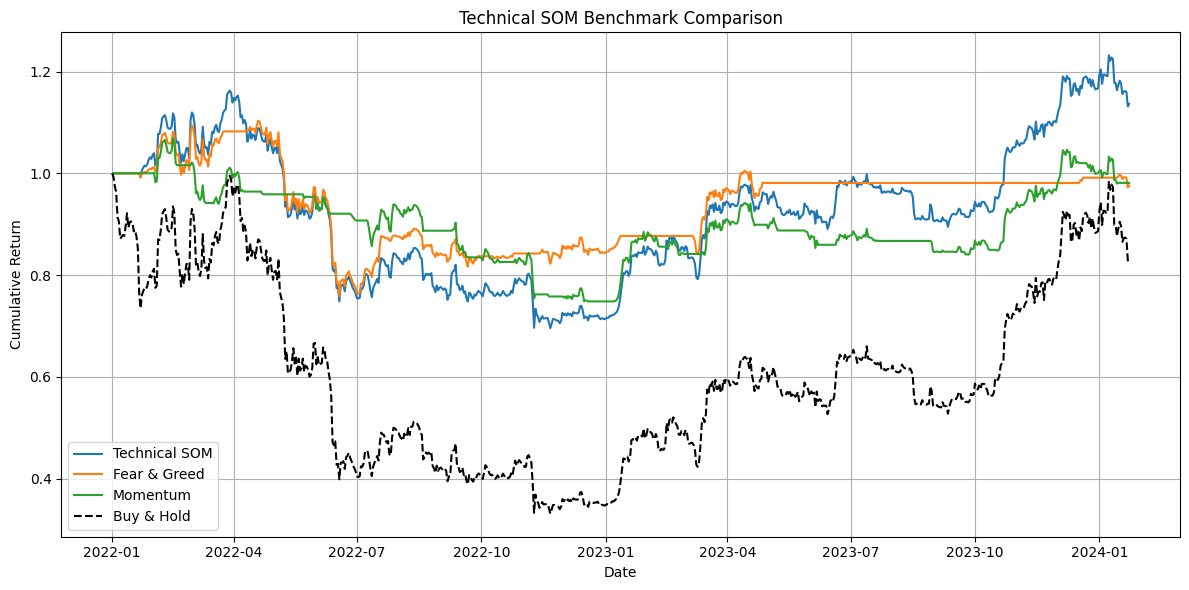


METRICS
Strategy                      Return   Sharpe   Drawdown  WinRate     PF   Trades
--------------------------------------------------------------------------------
Technical SOM                   1.14     0.30     40.16%   47.01%   1.06        3
Fear & Greed                    0.98     0.03     31.27%   24.97%   1.01       39
Momentum                        0.98     0.03     29.98%   27.36%   1.01      136
Buy & Hold                      0.84        —          —        —      —        —


In [57]:
test_df_cut_tech_with_vol = test_df_cut_tech.copy()
test_df_cut_tech_with_vol['Volume'] = df.loc[test_df_cut_tech.index, 'Volume']

results, metrics = compare_strategy(df, "Technical", test_df_cut_tech_with_vol)

## Sentiment SOM

In [8]:
sent_clusters, som_sent = train_som_model(
    data=train_val_df,
    feature_cols=best_features_map["sentiment"],
    model_name="sentiment",
    som_size=(15, 15),
    sigma=0.5,
    learning_rate=0.5,
    num_iter=1500,
    save_dir="models",
    to_save=False,
    to_print=True
)

Quantization Error: 0.0203
Topographic Error: 0.9691


In [15]:
stability_score = evaluate_cluster_stability(
    data=train_val_df,
    feature_cols=best_features_map["sentiment"],
    model_name="sentiment",
    som_size=(15, 15),
    sigma=0.5,
    learning_rate=0.5,
    num_iter=1500,
    save_dir="models",
    to_save=False,
    runs=20)
print(f"Cluster Stability: {stability_score:.4f}")

Cluster Stability: 0.9439


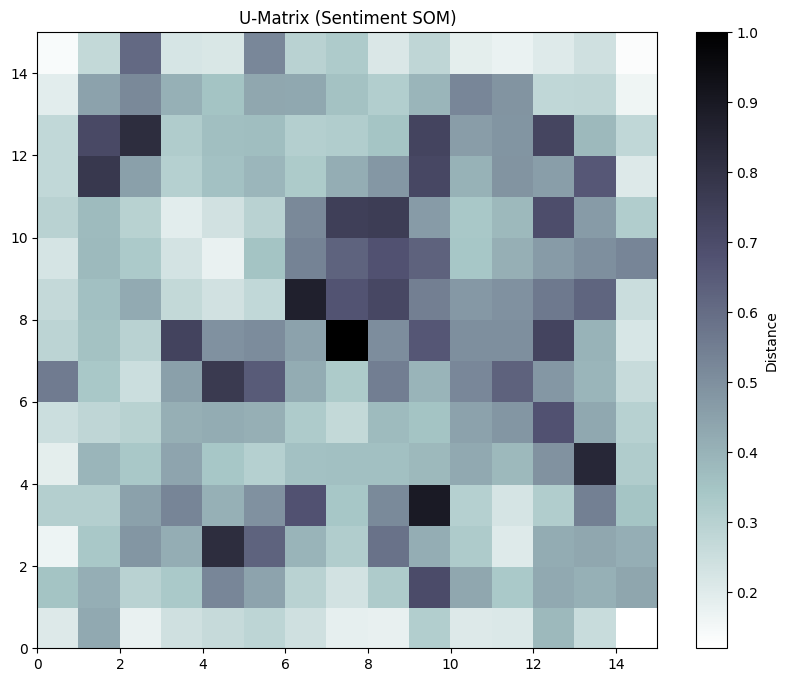

In [108]:
plot_umatrix(som_sent, title="U-Matrix (Sentiment SOM)")

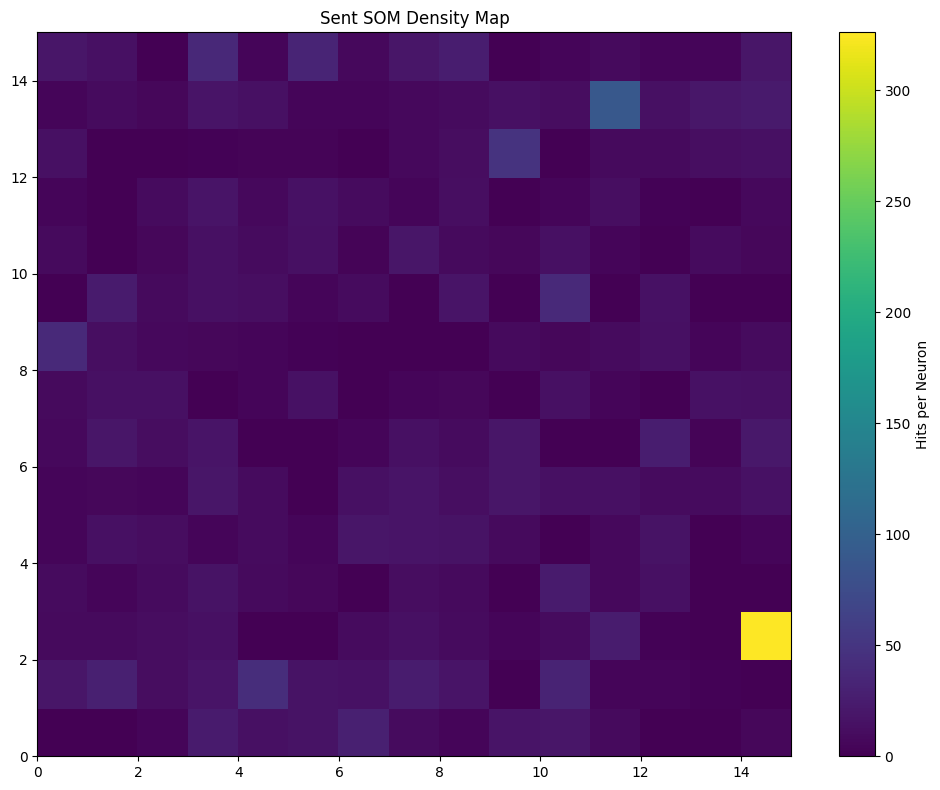

In [31]:
plot_density_map(som_sent, train_val_df[best_features_map["sentiment"]], title="Sent SOM Density Map")

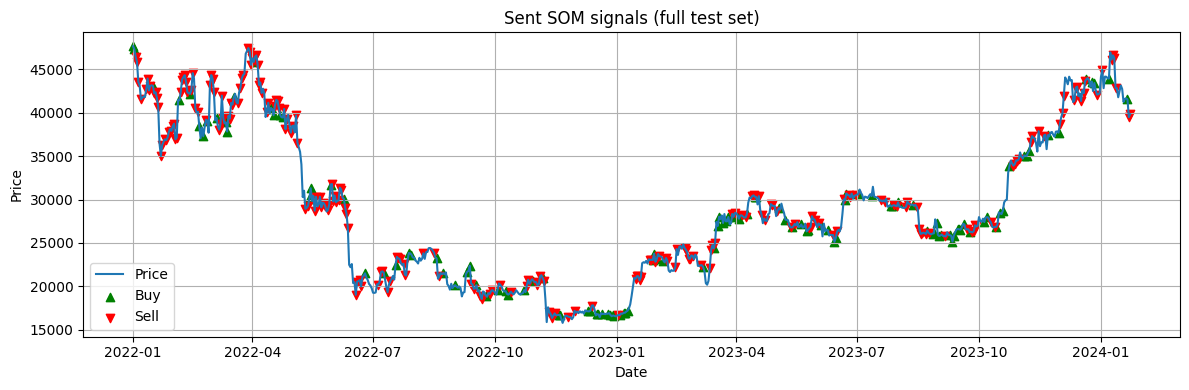

In [34]:
test_df_cut_sent, node_action_sent = process_and_signal(
    train_val_df, 
    test_df, 
    som_sent, 
    feature_cols=best_features_map["sentiment"], 
    model_name="sent", 
    save_dir="models"
)

In [27]:
print(test_df_cut_sent['signal'].value_counts())

hold    370
sell    224
buy     121
Name: signal, dtype: int64


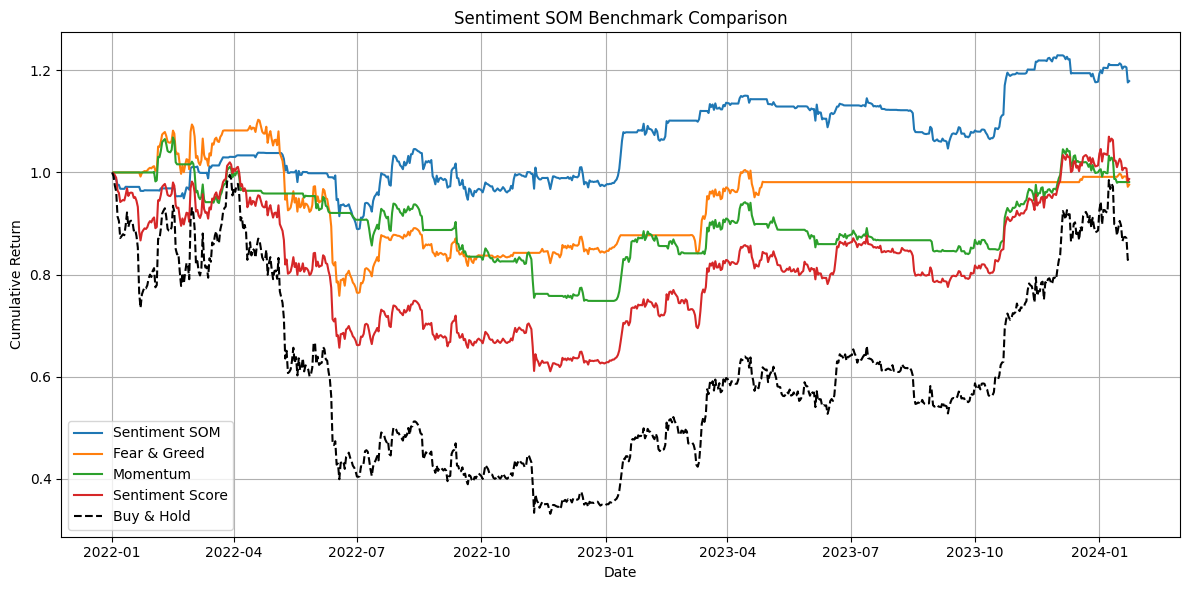


METRICS
Strategy                      Return   Sharpe   Drawdown  WinRate     PF   Trades
--------------------------------------------------------------------------------
Sentiment SOM                   1.18     0.51     14.44%   30.41%   1.14      256
Fear & Greed                    0.98     0.03     31.27%   24.97%   1.01       39
Momentum                        0.98     0.03     29.98%   27.36%   1.01      136
Sentiment Score                 0.99     0.09     40.16%   47.81%   1.02       11
Buy & Hold                      0.84        —          —        —      —        —


In [111]:
test_df_cut_sent_with_vol = test_df_cut_sent.copy()
test_df_cut_sent_with_vol['Volume'] = df.loc[test_df_cut_sent.index, 'Volume']
test_df_cut_sent_with_vol['avg_sentiment_score'] = df.loc[test_df_cut_sent.index, 'avg_sentiment_score']
results, metrics = compare_strategy(df, "Sentiment", test_df_cut_sent_with_vol)

## Hybrid SOM

In [10]:
hybrid_clusters, som_hybrid = train_som_model(
    data=train_val_df,
    feature_cols=best_features_map["hybrid"],
    model_name="hybrid",
    som_size=(15, 15),
    sigma=1.5,
    learning_rate=0.1,
    num_iter=1000,
    save_dir="models",
    to_save=False,
    to_print=True
)

Quantization Error: 0.2217
Topographic Error: 0.6914


In [124]:
stability_score = evaluate_cluster_stability(
    data=train_val_df,
    feature_cols=best_features_map["hybrid"],
    model_name="hybrid",
    som_size=(15, 15),
    sigma=1.5,
    learning_rate=0.1,
    num_iter=1000,
    save_dir="models",
    to_save=False,
    runs=20)
print(f"Cluster Stability: {stability_score:.4f}")

Cluster Stability: 1.0000


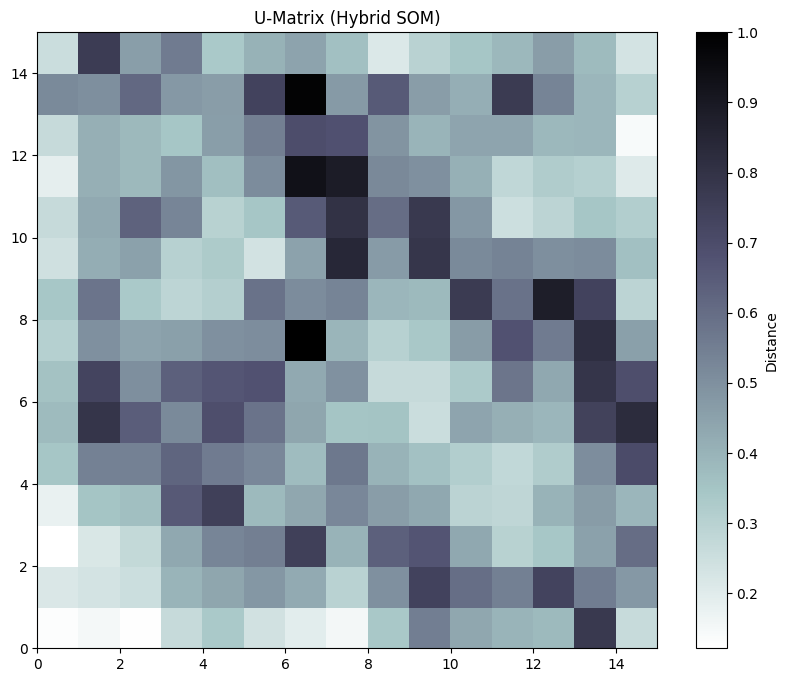

In [125]:
plot_umatrix(som_hybrid, title="U-Matrix (Hybrid SOM)")

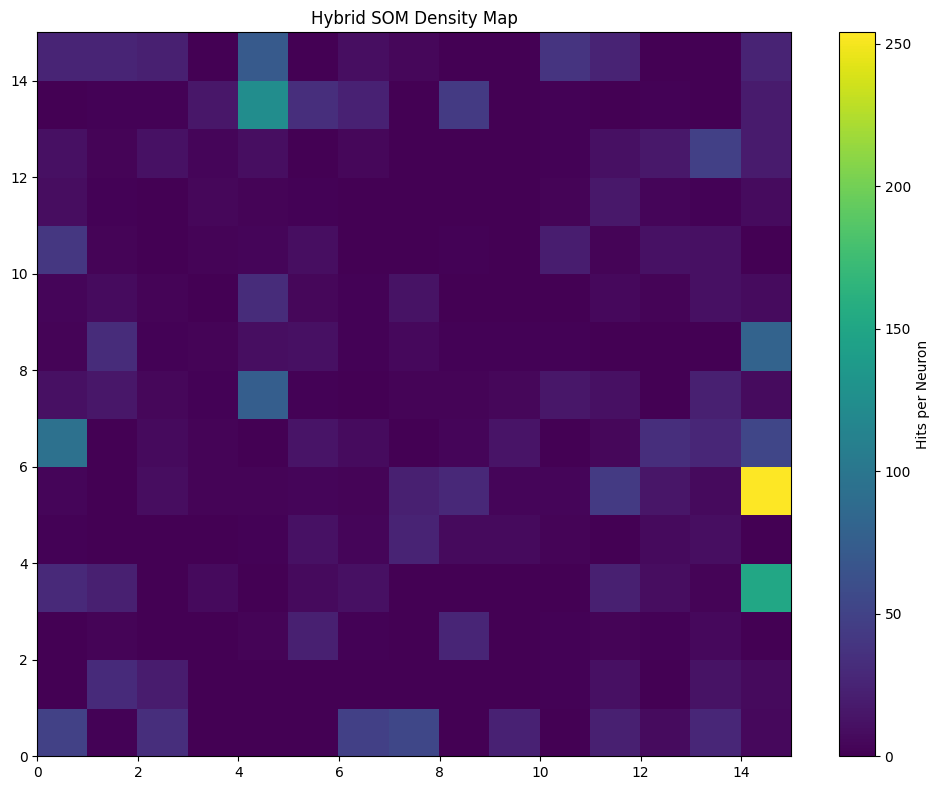

In [32]:
plot_density_map(som_hybrid, train_val_df[best_features_map["hybrid"]], title="Hybrid SOM Density Map")

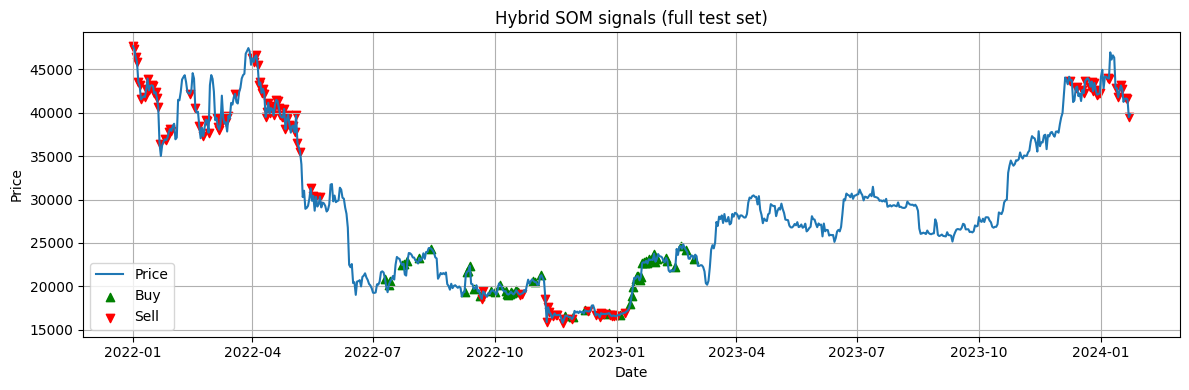

In [35]:
test_df_cut_hybrid, node_action_hybrid = process_and_signal(
    train_val_df, 
    test_df, 
    som_hybrid, 
    feature_cols=best_features_map["hybrid"], 
    model_name="hybrid", 
    save_dir="models"
)

In [30]:
print(test_df_cut_hybrid['signal'].value_counts())

hold    264
sell    126
buy      58
Name: signal, dtype: int64


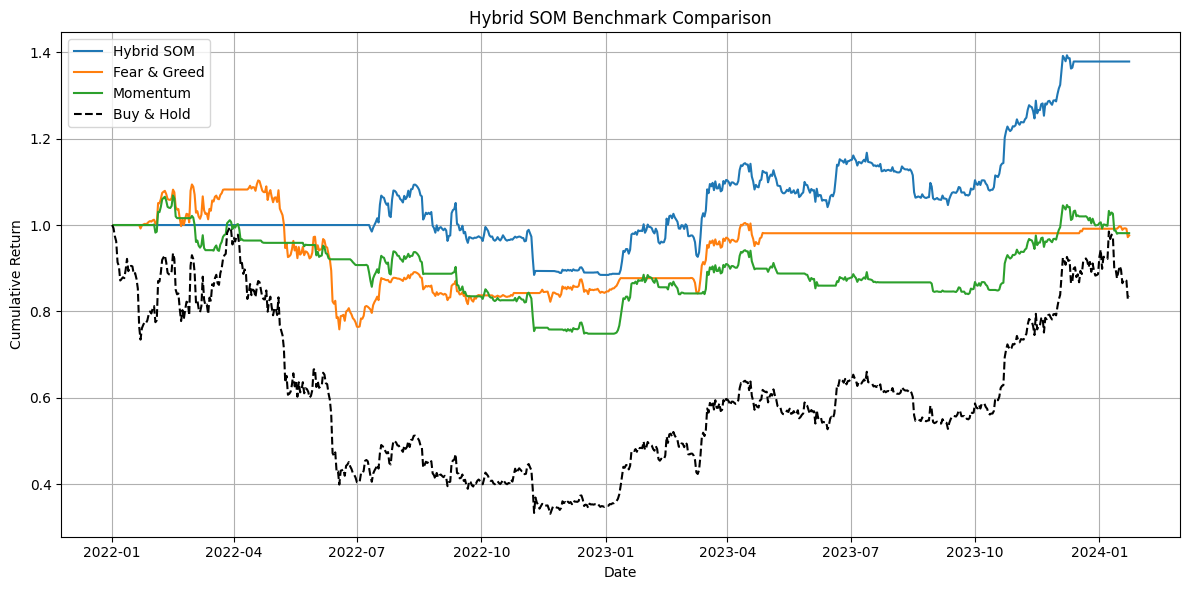


METRICS
Strategy                      Return   Sharpe   Drawdown  WinRate     PF   Trades
--------------------------------------------------------------------------------
Hybrid SOM                      1.38     0.78     19.14%   30.68%   1.21       32
Fear & Greed                    0.98     0.03     31.27%   24.97%   1.01       39
Momentum                        0.98     0.03     29.98%   27.36%   1.01      136
Buy & Hold                      0.84        —          —        —      —        —


In [128]:
test_df_cut_hybrid_with_vol = test_df_cut_hybrid.copy()
test_df_cut_hybrid_with_vol['Volume'] = df.loc[test_df_cut_hybrid.index, 'Volume']
results, metrics = compare_strategy(df, "Hybrid", test_df_cut_hybrid_with_vol)

## All SOMs comparison

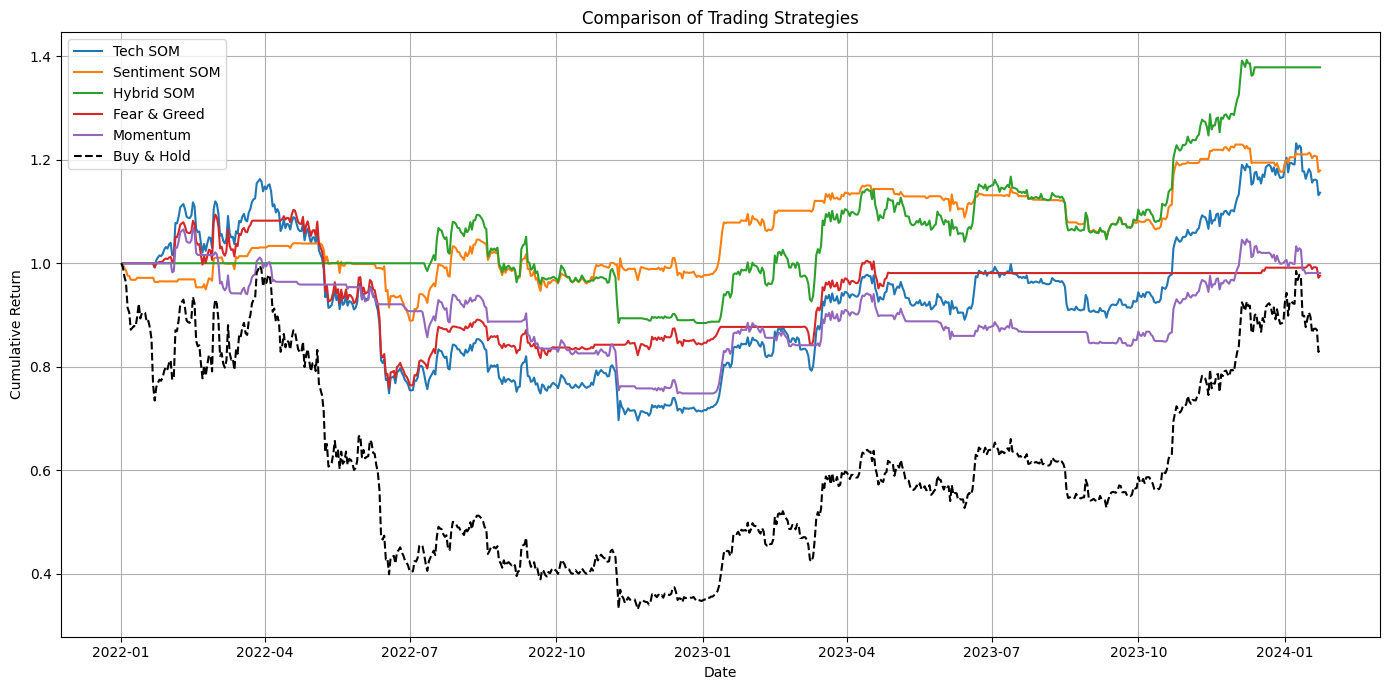


METRICS
Strategy                      Return   Sharpe   Drawdown  WinRate     PF   Trades
--------------------------------------------------------------------------------
Tech SOM                        1.14     0.30     40.16%   47.01%   1.06        3
Sentiment SOM                   1.18     0.51     14.44%   30.41%   1.14      256
Hybrid SOM                      1.38     0.78     19.14%   30.68%   1.21       32
Fear & Greed                    0.98     0.03     31.27%   24.97%   1.01       39
Momentum                        0.98     0.03     29.98%   27.36%   1.01      136
Buy & Hold                      0.84        —          —        —      —        —


In [129]:
som_dfs = {
    'technical': test_df_cut_tech,
    'sentiment': test_df_cut_sent,
    'hybrid': test_df_cut_hybrid
}

model_prefixes = {
    'technical': 'Tech SOM',
    'sentiment': 'Sentiment SOM',
    'hybrid': 'Hybrid SOM'
}

strategies = compare_trading_strategies(
    df_full=df,
    som_dfs=som_dfs,
    model_prefixes=model_prefixes,
    df_signals=None,
    price_col='Close',
    to_plot_signals=True
)

## Ensemble SOM

In [37]:
# Make sure the indices are aligned (Date index)
df_signals = pd.DataFrame(index=test_df_cut_tech.index)

# Add price column from one of them (they should all match)
df_signals['Close'] = test_df_cut_tech['Close']

# Add signals from each strategy
df_signals['signal_tech'] = test_df_cut_tech['signal']
df_signals['signal_sent'] = test_df_cut_sent['signal']
df_signals['signal_hybrid'] = test_df_cut_hybrid['signal']


In [32]:
df_signals.head()

,Close,signal_tech,signal_sent,signal_hybrid
Date,,,,
2022-01-01,47686.812500,hold,buy,sell
2022-01-02,47345.218750,hold,buy,sell
2022-01-03,46458.117188,hold,sell,sell
2022-01-04,45897.574219,hold,sell,sell
2022-01-05,43569.003906,hold,sell,sell


### majority voting

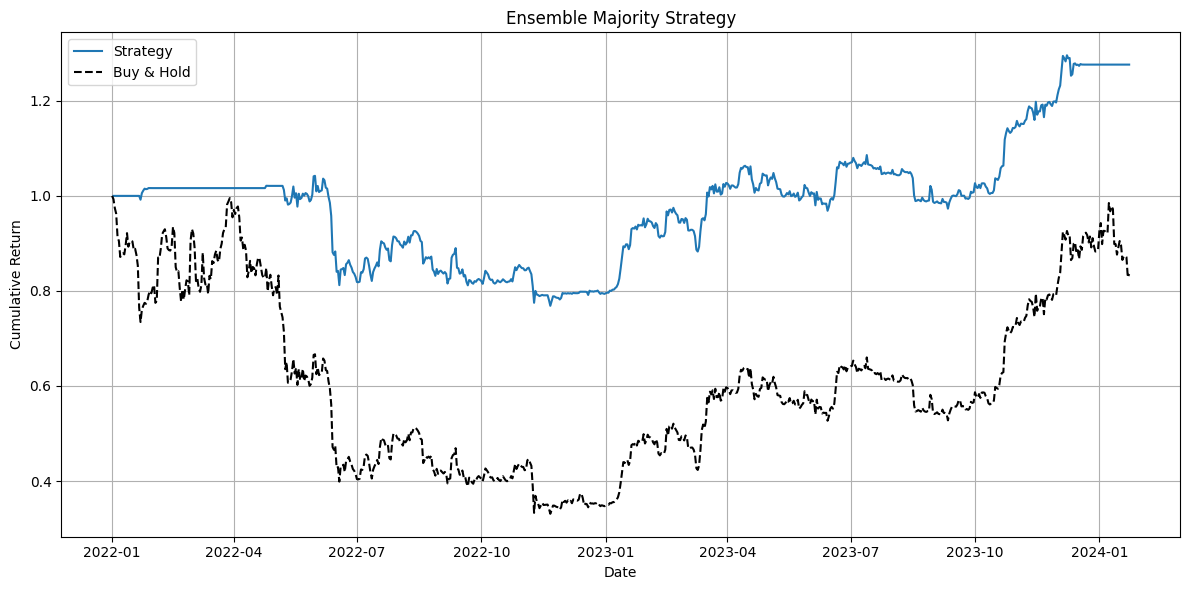

{'Cumulative Return': 1.2762319454500177, 'Sharpe Ratio': 0.5450663448220995, 'Max Drawdown': 0.26246505758306765, 'Win Rate': 0.38114209827357237, 'Profit Factor': 1.1280170409905672, 'Number of Trades': 50}


In [33]:
metrics, df_signals = run_majority_ensemble(df_signals)
print(metrics)

### weighted voting ensemble

In [ ]:
import numpy as np
import pandas as pd

# store the best result
best_metrics = None
best_weights = None
best_score = -np.inf
results = []

# search grid (in steps of 0.1)
steps = np.arange(0, 1.1, 0.1)

for w_tech in steps:
    for w_sent in steps:
        for w_hyb in steps:
            total = w_tech + w_sent + w_hyb
            if total == 0:
                continue  # skip all-zero weights
            # Normalize weights to sum to 1
            weights = {
                'signal_tech': w_tech / total,
                'signal_sent': w_sent / total,
                'signal_hybrid': w_hyb / total
            }

            try:
                metrics, _ = run_weighted_ensemble(df_signals.copy(), weights, to_plot=False)
                score = metrics['Cumulative Return'] 

                results.append((weights, score))

                if score > best_score:
                    best_score = score
                    best_weights = weights
                    best_metrics = metrics

            except Exception as e:
                print(f"Skipping weights {weights} due to error: {e}")

# print best result
print("\nBest weights:", best_weights)
print("Best Cumulative Return:", best_score)
print("Full metrics:", best_metrics)

# convert results to DataFrame for analysis
results_df = pd.DataFrame([
    {
        'w_tech': w['signal_tech'],
        'w_sent': w['signal_sent'],
        'w_hyb': w['signal_hybrid'],
        'Cumulative Return': s
    } for w, s in results
])



Best weights: {'signal_tech': 0.2, 'signal_sent': 0.2, 'signal_hybrid': 0.6000000000000001}
Best Cumulative Return: 1.4649615987636835
Full metrics: {'Cumulative Return': 1.4649615987636835, 'Sharpe Ratio': 0.9168665735290629, 'Max Drawdown': 0.1529994005654317, 'Win Rate': 0.32270916334661354, 'Profit Factor': 1.2371087561043452, 'Number of Trades': 66}


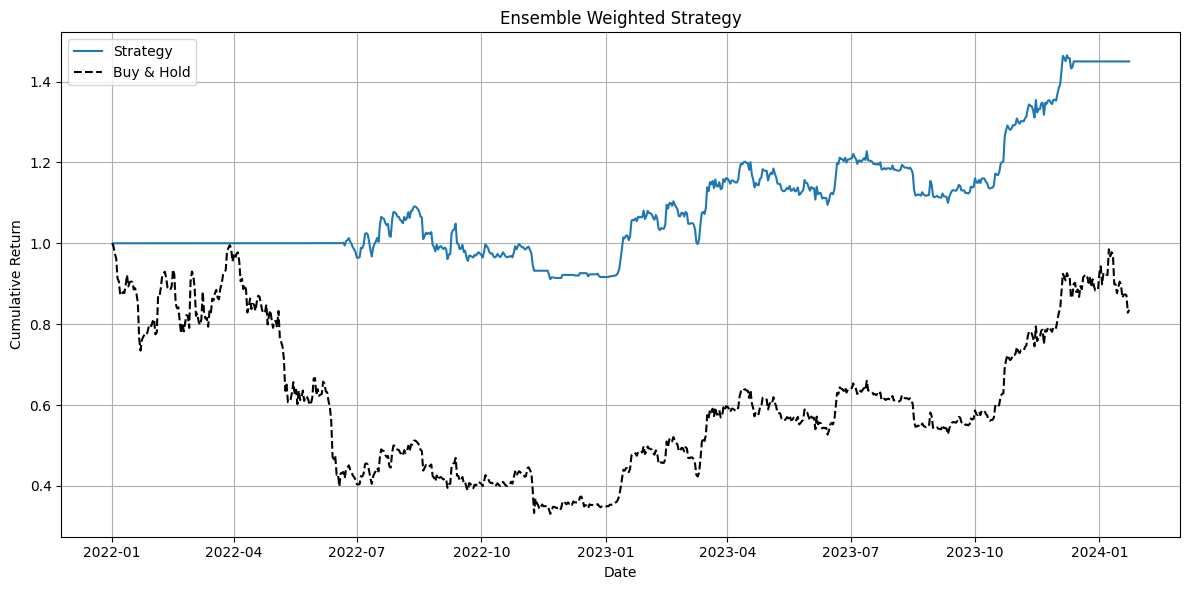

{'Cumulative Return': 1.4496475354733886, 'Sharpe Ratio': 0.8914815174867177, 'Max Drawdown': 0.16490951761961223, 'Win Rate': 0.3187250996015936, 'Profit Factor': 1.2305168656018193, 'Number of Trades': 58}


In [34]:
weights = {'signal_tech': 0.2, 'signal_sent': 0.2, 'signal_hybrid': 0.6000000000000001}
metrics, df_signals = run_weighted_ensemble(df_signals, weights)
print(metrics)

### unanimous strategy (conservative)

only act when they all agree to avoid false positives

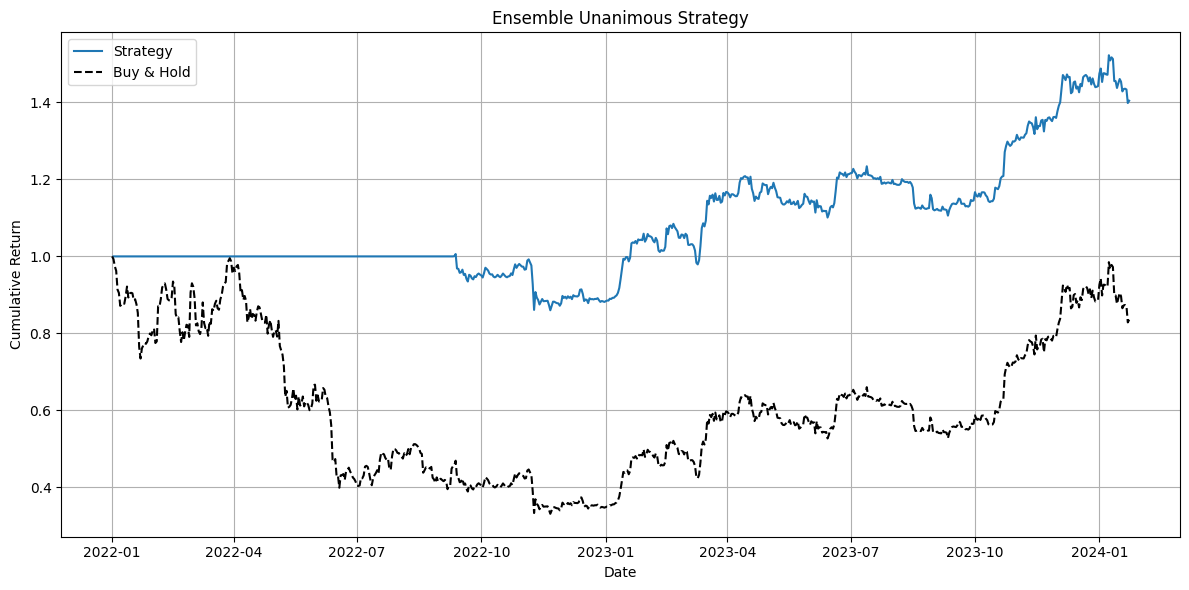

{'Cumulative Return': 1.4045730093011712, 'Sharpe Ratio': 0.8080310264586243, 'Max Drawdown': 0.14523151334046708, 'Win Rate': 0.3200531208499336, 'Profit Factor': 1.2126767498140973, 'Number of Trades': 3}


In [38]:
metrics, df_signals = run_unanimous_ensemble(df_signals)
print(metrics)

In [39]:
df_signals

,Close,signal_tech,signal_sent,signal_hybrid,ensemble_unanimous
Date,,,,,
2022-01-01,47686.812500,hold,buy,sell,hold
2022-01-02,47345.218750,hold,buy,sell,hold
2022-01-03,46458.117188,hold,sell,sell,hold
2022-01-04,45897.574219,hold,sell,sell,hold
2022-01-05,43569.003906,hold,sell,sell,hold
...,...,...,...,...,...
2024-01-19,41618.406250,hold,hold,hold,hold
2024-01-20,41665.585938,hold,hold,sell,hold
2024-01-21,41545.785156,hold,buy,sell,hold


In [40]:
print(df_signals['ensemble_unanimous'].value_counts())

hold    747
buy       4
Name: ensemble_unanimous, dtype: int64


### aggressive strategy

act on any strong signal (e.g., favor buy/sell even if only one says so)

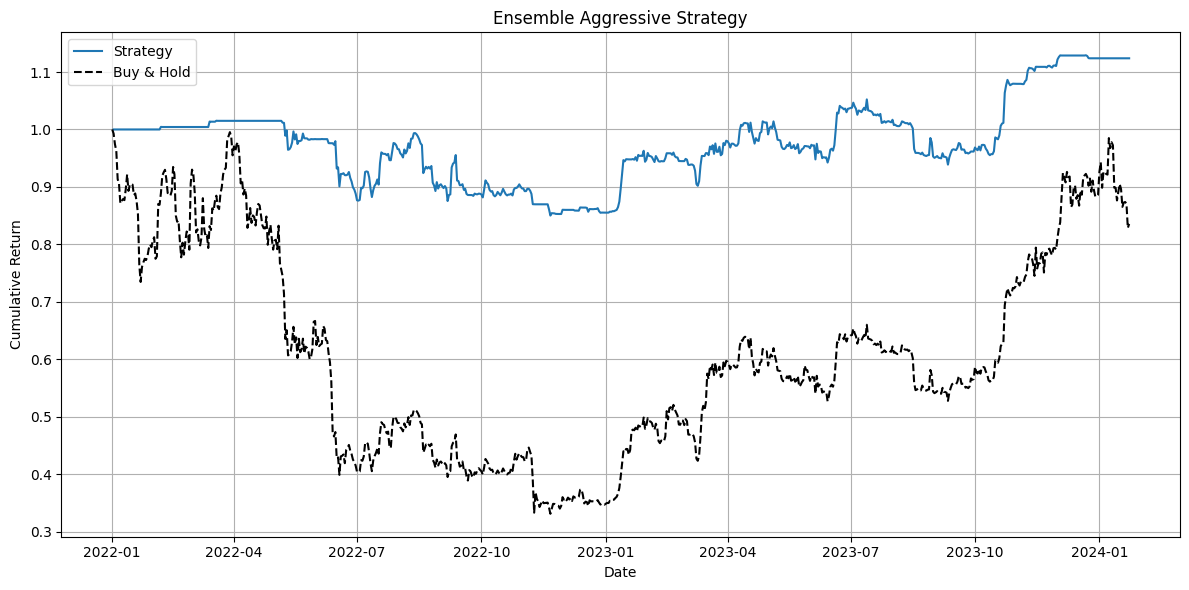

{'Cumulative Return': 1.1238735806936913, 'Sharpe Ratio': 0.3586632066403233, 'Max Drawdown': 0.16259308746464093, 'Win Rate': 0.30677290836653387, 'Profit Factor': 1.0939597912046664, 'Number of Trades': 268}


In [36]:
metrics, df_signals = run_aggressive_ensemble(df_signals)
print(metrics)

### probabilistic voting

for visualizing how "confident" the ensemble is

In [37]:
df_with_probs = run_probabilistic_ensemble(df_signals)
df_with_probs.head()

,Close,signal_tech,signal_sent,signal_hybrid,ensemble_signal,ensemble_weighted,ensemble_unanimous,ensemble_aggressive,buy_prob,hold_prob,sell_prob
Date,,,,,,,,,,,
2022-01-01,47686.812500,hold,buy,sell,hold,sell,hold,sell,0.333333,0.333333,0.333333
2022-01-02,47345.218750,hold,buy,sell,hold,sell,hold,sell,0.333333,0.333333,0.333333
2022-01-03,46458.117188,hold,sell,sell,sell,sell,hold,sell,0.000000,0.333333,0.666667
2022-01-04,45897.574219,hold,sell,sell,sell,sell,hold,sell,0.000000,0.333333,0.666667
2022-01-05,43569.003906,hold,sell,sell,sell,sell,hold,sell,0.000000,0.333333,0.666667


In [138]:
df_signals.head()

,Close,signal_tech,signal_sent,signal_hybrid,ensemble_signal,ensemble_weighted,ensemble_aggressive
Date,,,,,,,
2022-01-01,47686.812500,hold,buy,sell,hold,hold,sell
2022-01-02,47345.218750,hold,buy,sell,hold,hold,sell
2022-01-03,46458.117188,hold,hold,sell,hold,hold,sell
2022-01-04,45897.574219,hold,sell,sell,sell,hold,sell
2022-01-05,43569.003906,hold,sell,sell,sell,hold,sell


### compare all trading strategies

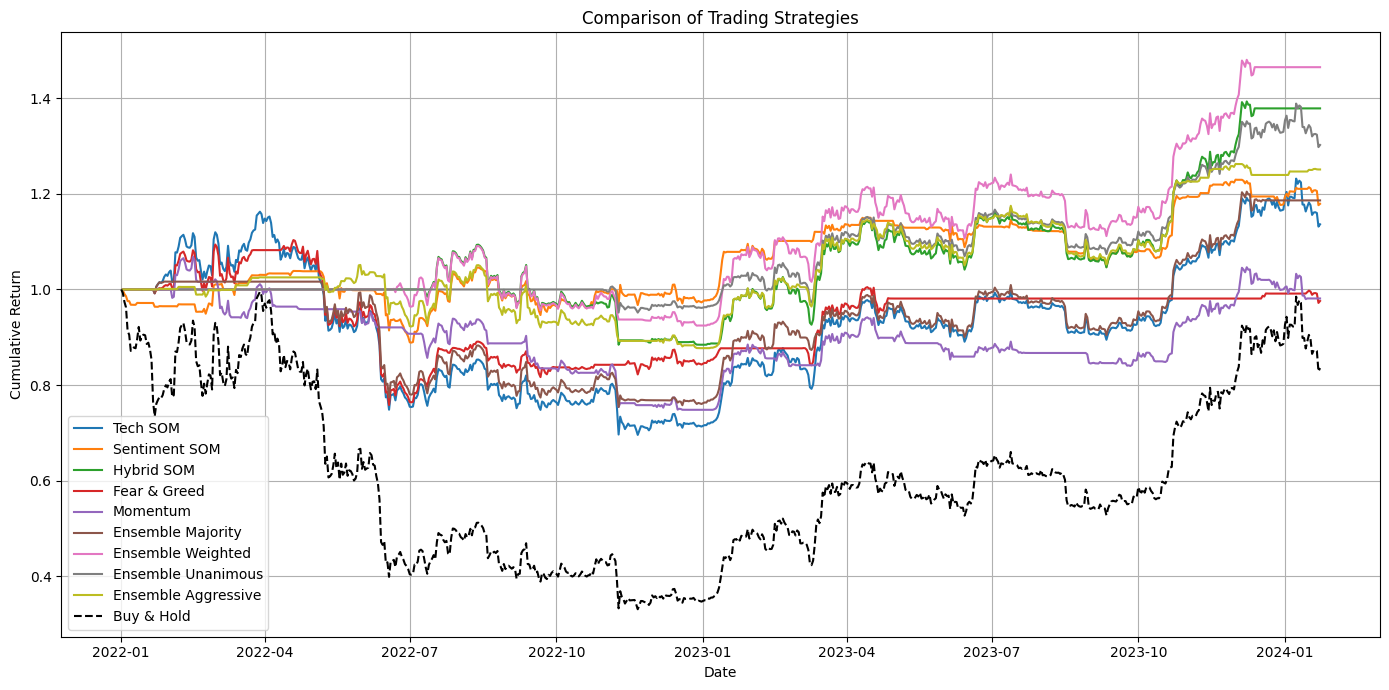


METRICS
Strategy                      Return   Sharpe   Drawdown  WinRate     PF   Trades
--------------------------------------------------------------------------------
Tech SOM                        1.14     0.30     40.16%   47.01%   1.06        3
Sentiment SOM                   1.18     0.51     14.44%   30.41%   1.14      256
Hybrid SOM                      1.38     0.78     19.14%   30.68%   1.21       32
Fear & Greed                    0.98     0.03     31.27%   24.97%   1.01       39
Momentum                        0.98     0.03     29.98%   27.36%   1.01      136
Ensemble Majority               1.19     0.41     25.82%   37.05%   1.10       52
Ensemble Weighted               1.46     0.92     15.30%   32.27%   1.24       66
Ensemble Unanimous              1.30     0.88      8.37%   28.95%   1.25        2
Ensemble Aggressive             1.25     0.58     16.56%   33.86%   1.15      296
Buy & Hold                      0.84        —          —        —      —        —


In [159]:
strategies = compare_trading_strategies(
    df_full=df,
    som_dfs=som_dfs,
    model_prefixes=model_prefixes,
    df_signals=df_signals,
    price_col='Close',
    to_plot_signals=True
)


## Market Regime Testing

In [5]:
def label_market_regimes(df, price_col="Close", window=20):
    df = df.copy()
    df["returns"] = df[price_col].pct_change(window)
    df["regime"] = "sideways"
    df.loc[df["returns"] > 0.05, "regime"] = "bull"
    df.loc[df["returns"] < -0.05, "regime"] = "bear"
    return df


In [6]:
df_with_regimes = label_market_regimes(df)

--- Evaluating in bull market ---


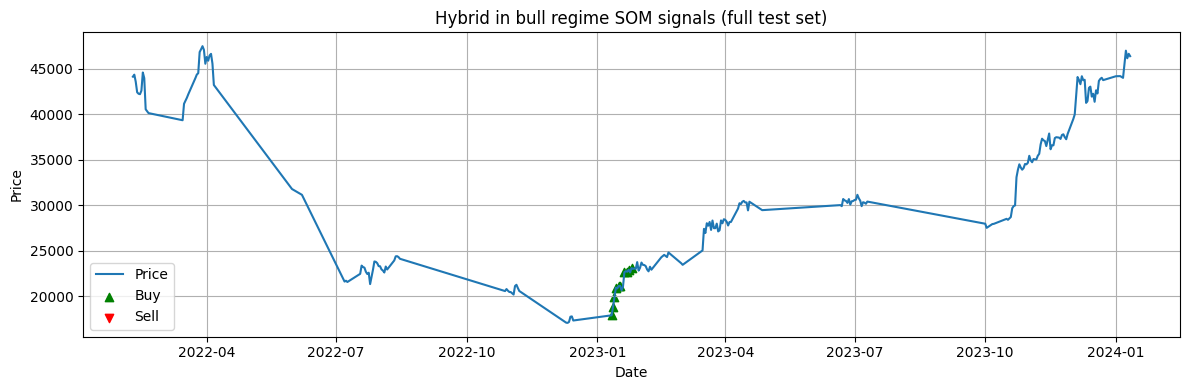


METRICS
Strategy                      Return   Sharpe   Drawdown  WinRate     PF   Trades
--------------------------------------------------------------------------------
Hybrid in bull regime SOM       1.59     3.15      5.90%   37.61%   2.05        3
Fear & Greed                    0.96    -0.06     27.04%   33.76%   0.98       20
Momentum                        1.12     0.71     18.19%   38.03%   1.18       29
Buy & Hold                      1.05        —          —        —      —        —
--- Evaluating in bear market ---


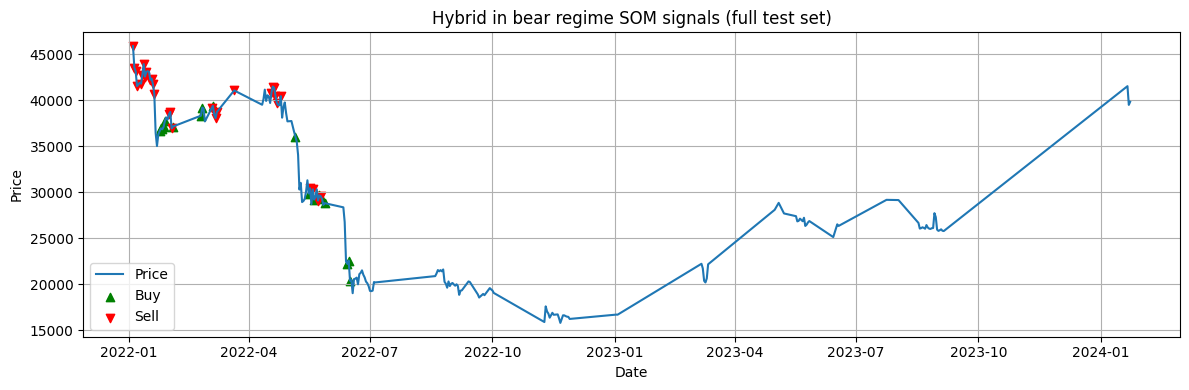


METRICS
Strategy                      Return   Sharpe   Drawdown  WinRate     PF   Trades
--------------------------------------------------------------------------------
Hybrid in bear regime SOM       1.28     0.85     25.87%   36.97%   1.34       25
Fear & Greed                    1.34     1.67      6.58%   24.17%   1.86       11
Momentum                        1.10     0.57     13.42%   18.48%   1.25       41
Buy & Hold                      0.87        —          —        —      —        —
--- Evaluating in sideways market ---


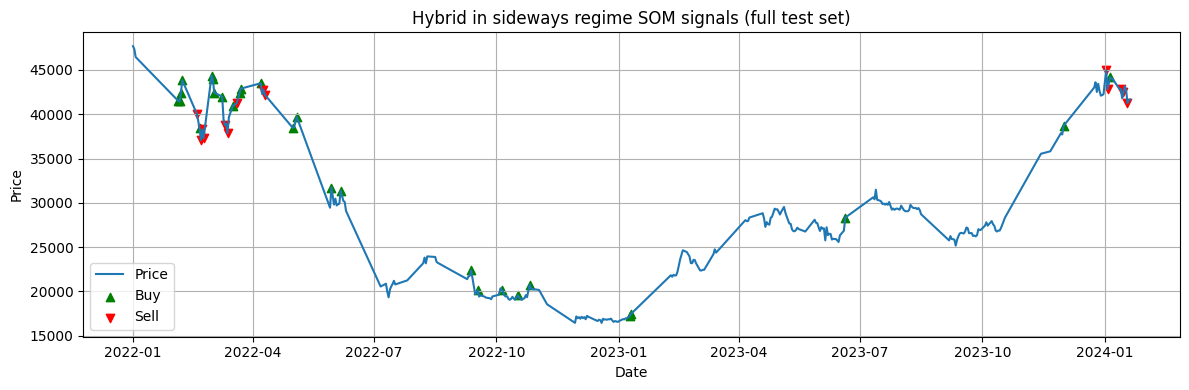


METRICS
Strategy                      Return   Sharpe   Drawdown  WinRate     PF   Trades
--------------------------------------------------------------------------------
Hybrid in sideways regime SOM       1.00     0.17     41.10%   45.45%   1.05       26
Fear & Greed                    0.83    -0.43     31.94%   35.71%   0.88       28
Momentum                        1.23     0.86     21.47%   24.03%   1.34       55
Buy & Hold                      0.87        —          —        —      —        —


In [8]:
for regime in ['bull', 'bear', 'sideways']:
    print(f"--- Evaluating in {regime} market ---")
    
    # Subset for regime
    regime_df = df_with_regimes[df_with_regimes["regime"] == regime]

    # Split regime_df into regime-specific train/val and test
    regime_train_val = regime_df[regime_df.index <= train_val_df.index[-1]]
    regime_test = regime_df[regime_df.index > train_val_df.index[-1]]

    # Train SOM on regime-specific data
    clusters, som = train_som_model(
        data=regime_train_val,
        feature_cols=best_features_map["hybrid"],
        model_name=f"Hybrid in {regime} regime",
        som_size=(15, 15),
        sigma=1.5,
        learning_rate=0.1,
        num_iter=1000,
        save_dir="models",
        to_save=False
    )

    # Apply to regime-specific test data
    test_df_cut_tech, node_action_tech = process_and_signal(
        regime_train_val, 
        regime_test, 
        som, 
        feature_cols=best_features_map["hybrid"], 
        model_name=f"Hybrid in {regime} regime", 
        save_dir="models"
    )

    # If needed, add Volume or other columns
    test_df_cut_tech['Volume'] = regime_test.loc[test_df_cut_tech.index, 'Volume']

    # Compare strategies on that regime only
    results, metrics = compare_strategy(
        df_full=regime_df,  # or the full original dataset if fear/greed requires it
        model_name=f"Hybrid in {regime} regime",
        test_df_cut=test_df_cut_tech,
        to_plot_signals=False
    )


## Test on a single day

In [20]:
# Choose a significant day
selected_day = "2022-11-08"

# Ensure the index is datetime
df_signals.index = pd.to_datetime(df_signals.index)

# Extract the row for that day
row = df_signals.loc[selected_day]

# Apply each ensemble strategy
maj_signal = majority_vote(row)
w_signal = weighted_vote(row, weights={'signal_tech': 0.4, 'signal_sent': 0.4, 'signal_hybrid': 0.2})
uni_signal = unanimous_vote(row)
agg_signal = aggressive_vote(row)
probs = probabilistic_vote(row)

# Display results
print(f"Signals on {selected_day}")
print(f"  Technical SOM: {row['signal_tech']}")
print(f"  Sentiment SOM: {row['signal_sent']}")
print(f"  Hybrid SOM: {row['signal_hybrid']}")
print(f"  Majority: {maj_signal}")
print(f"  Weighted: {w_signal}")
print(f"  Unanimous: {uni_signal}")
print(f"  Aggressive: {agg_signal}")
print(f"  Probabilities: {probs}")


Signals on 2022-11-08
  Technical SOM: hold
  Sentiment SOM: hold
  Hybrid SOM: sell
  Majority: hold
  Weighted: hold
  Unanimous: hold
  Aggressive: sell
  Probabilities: {'buy_prob': 0.0, 'hold_prob': 0.6666666666666666, 'sell_prob': 0.3333333333333333}


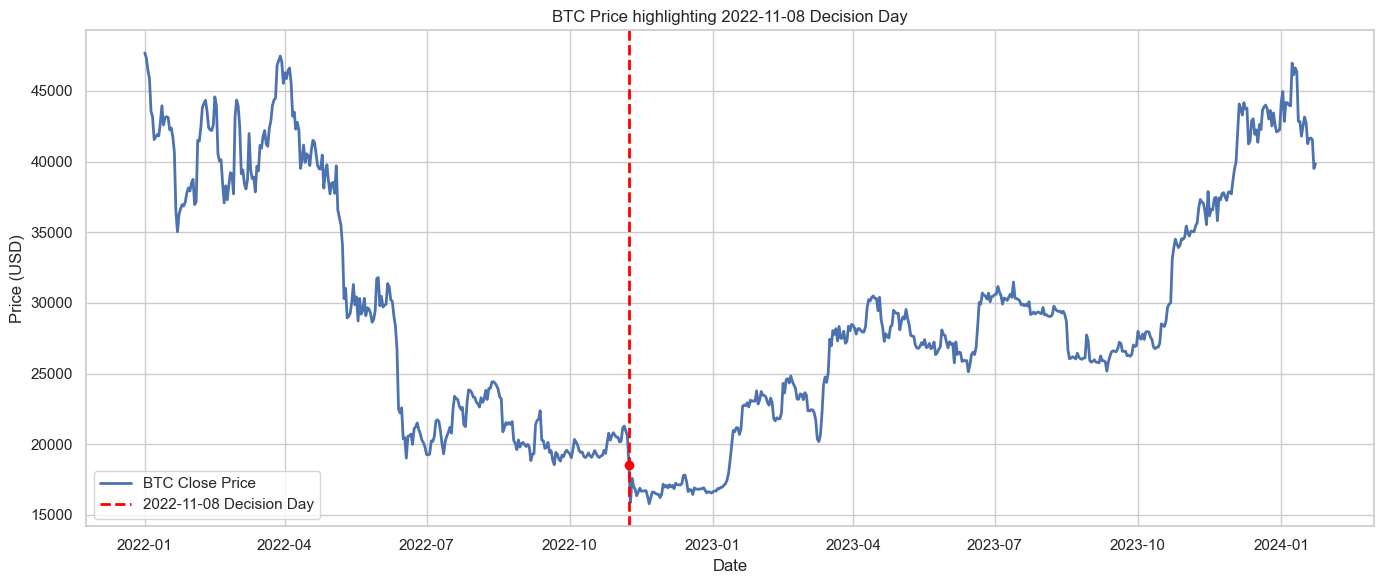

In [40]:
import seaborn as sns
sns.set(style="whitegrid")

plt.figure(figsize=(14, 6))
plt.plot(df_signals.index, df_signals['Close'], label='BTC Close Price', linewidth=2)
plt.axvline(pd.to_datetime(selected_day), color='red', linestyle='--', label=f'{selected_day} Decision Day', linewidth=2)

# Realçar o ponto da decisão
price_on_day = df_signals.loc[selected_day, 'Close']
plt.scatter(pd.to_datetime(selected_day), price_on_day, color='red', zorder=5)

plt.title(f"BTC Price highlighting {selected_day} Decision Day")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.tight_layout()
plt.show()


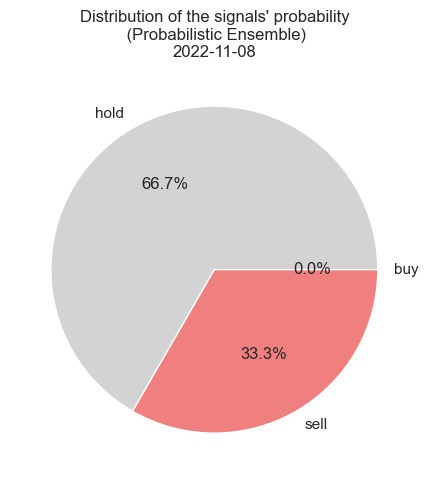

In [69]:
import matplotlib.pyplot as plt

# Softer pastel-like colors
soft_colors = ['lightgreen', 'lightgray', 'lightcoral']

plt.figure(figsize=(5, 5))
plt.pie(
    probs.values(),
    labels=[k.replace('_prob', '') for k in probs.keys()],
    autopct='%1.1f%%',
    colors=soft_colors
)
plt.title(f"Distribution of the signals' probability\n (Probabilistic Ensemble)\n{selected_day}")
plt.tight_layout()
plt.show()


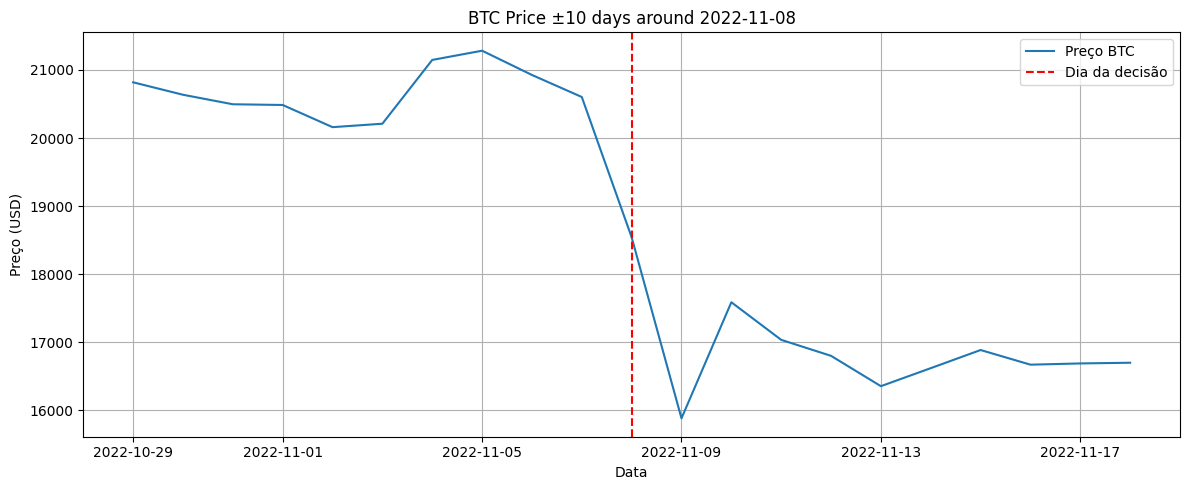

In [39]:
buffer_days = 10
start = pd.to_datetime(selected_day) - pd.Timedelta(days=buffer_days)
end = pd.to_datetime(selected_day) + pd.Timedelta(days=buffer_days)

plt.figure(figsize=(12, 5))
plt.plot(df_signals.loc[start:end].index, df_signals.loc[start:end]['Close'], label='Preço BTC')
plt.axvline(pd.to_datetime(selected_day), color='red', linestyle='--', label='Dia da decisão')
plt.title(f"BTC Price ±{buffer_days} days around {selected_day}")
plt.xlabel("Data") 
plt.ylabel("Preço (USD)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [42]:
df_signals.head()

,Close,signal_tech,signal_sent,signal_hybrid,ensemble_signal,ensemble_weighted,ensemble_unanimous,ensemble_aggressive
Date,,,,,,,,
2022-01-01,47686.812500,hold,buy,sell,hold,sell,hold,sell
2022-01-02,47345.218750,hold,buy,sell,hold,sell,hold,sell
2022-01-03,46458.117188,hold,sell,sell,sell,sell,hold,sell
2022-01-04,45897.574219,hold,sell,sell,sell,sell,hold,sell
2022-01-05,43569.003906,hold,sell,sell,sell,sell,hold,sell


BMU coordinates for 2022-11-08: (14, 5)


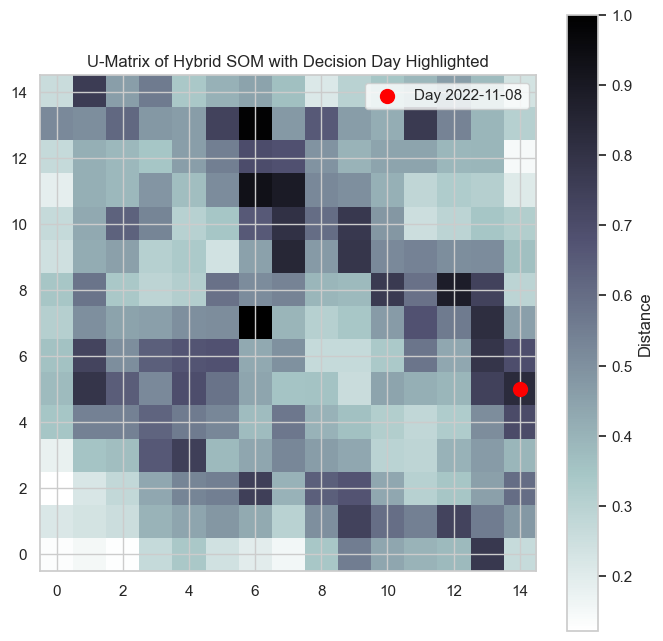

In [52]:
# Get the scaled input data used for SOM training
X_hybrid = train_val_df[best_features_map["hybrid"]].values

# Get the index of the selected day in the training data
selected_date = "2022-11-08"
test_day_vector = test_df.loc[selected_date, best_features_map["hybrid"]].values.reshape(1, -1)

bmu_coords = som_hybrid.winner(test_day_vector[0])
print("BMU coordinates for {}: {}".format(selected_date, bmu_coords))

u_matrix = som_hybrid.distance_map()

plt.figure(figsize=(8, 8))
plt.imshow(u_matrix.T, cmap='bone_r', origin='lower')
plt.colorbar(label='Distance')

# Destacar o BMU
plt.scatter(bmu_coords[0], bmu_coords[1], c='red', s=100, label=f'Day {selected_date}')
plt.legend()
plt.title("U-Matrix of Hybrid SOM with Decision Day Highlighted")
plt.show()

BMU coordinates for 2022-11-08: (7, 7)


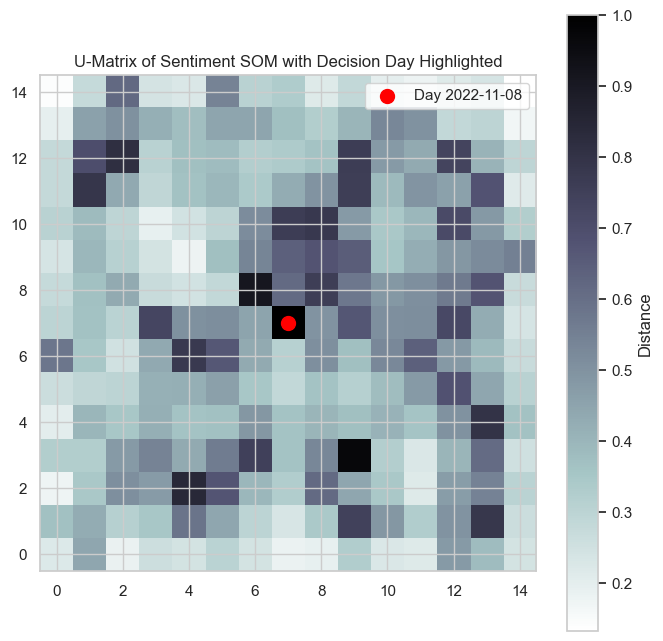

In [53]:
# Get the scaled input data used for SOM training
X_sent = train_val_df[best_features_map["sentiment"]].values

# Get the index of the selected day in the training data
selected_date = "2022-11-08"
test_day_vector = test_df.loc[selected_date, best_features_map["sentiment"]].values.reshape(1, -1)

bmu_coords = som_sent.winner(test_day_vector[0])
print("BMU coordinates for {}: {}".format(selected_date, bmu_coords))

u_matrix = som_sent.distance_map()

plt.figure(figsize=(8, 8))
plt.imshow(u_matrix.T, cmap='bone_r', origin='lower')
plt.colorbar(label='Distance')

# Destacar o BMU
plt.scatter(bmu_coords[0], bmu_coords[1], c='red', s=100, label=f'Day {selected_date}')
plt.legend()
plt.title("U-Matrix of Sentiment SOM with Decision Day Highlighted")
plt.show()

BMU coordinates for 2022-11-08: (18, 0)


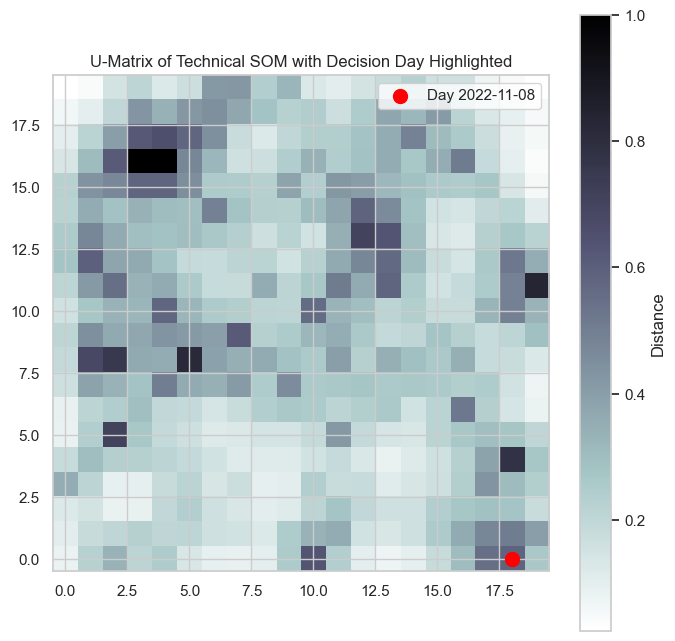

In [54]:
# Get the scaled input data used for SOM training
X_tech = train_val_df[best_features_map["technical"]].values

# Get the index of the selected day in the training data
selected_date = "2022-11-08"
test_day_vector = test_df.loc[selected_date, best_features_map["technical"]].values.reshape(1, -1)

bmu_coords = som_tech.winner(test_day_vector[0])
print("BMU coordinates for {}: {}".format(selected_date, bmu_coords))

u_matrix = som_tech.distance_map()

plt.figure(figsize=(8, 8))
plt.imshow(u_matrix.T, cmap='bone_r', origin='lower')
plt.colorbar(label='Distance')

# Destacar o BMU
plt.scatter(bmu_coords[0], bmu_coords[1], c='red', s=100, label=f'Day {selected_date}')
plt.legend()
plt.title("U-Matrix of Technical SOM with Decision Day Highlighted")
plt.show()

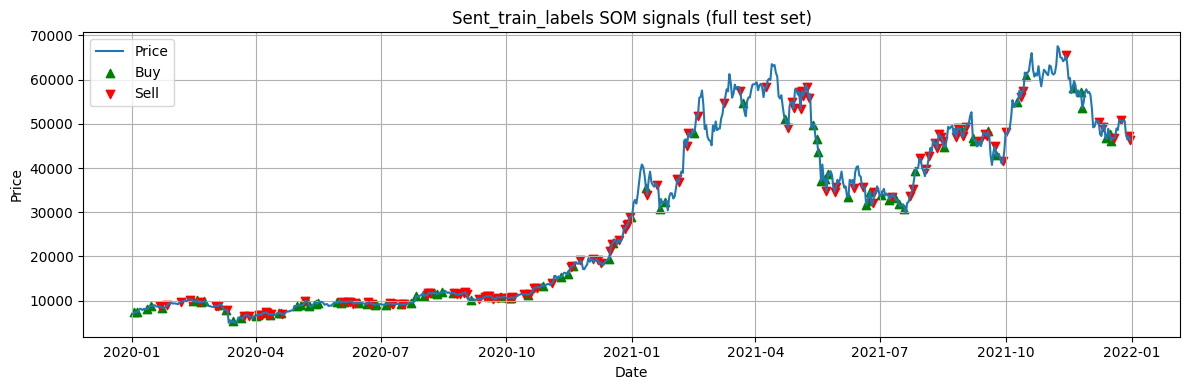

In [17]:

_, node_action_sent_train = process_and_signal(
    train_df,     # train set
    val_df,     
    som_sent,         
    feature_cols=best_features_map["sentiment"],
    model_name="sent_train_labels",
    save_dir="models"
)


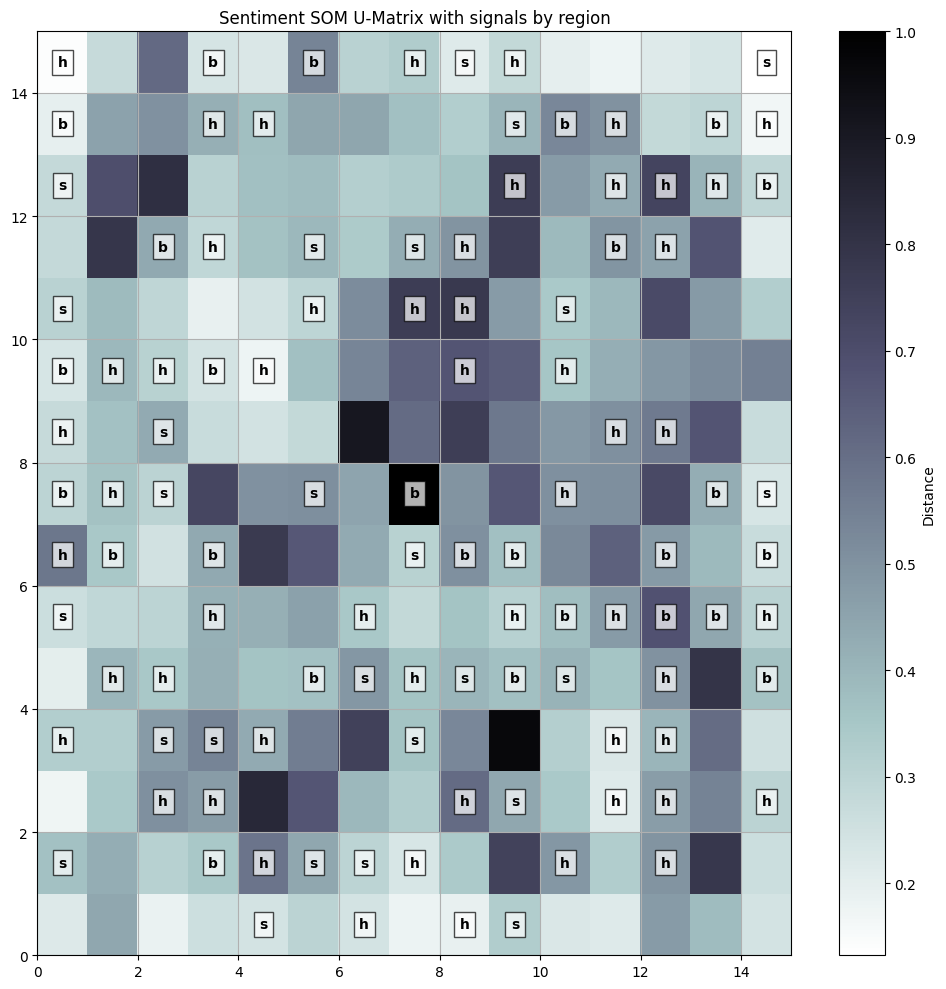

In [18]:
import matplotlib.pyplot as plt
import numpy as np

# Obter o mapa de distâncias (U-Matrix)
u_matrix = som_sent.distance_map().T  # transpor para que (x,y) fiquem corretos

plt.figure(figsize=(10, 10))
plt.pcolor(u_matrix, cmap='bone_r')
plt.colorbar(label='Distance')
plt.title("Sentiment SOM U-Matrix with signals by region")

# Adicionar texto nas células com o sinal atribuído ao BMU
for key, signal in node_action_sent_train.items():
    x, y = map(int, key.split('_'))
    plt.text(x + 0.5, y + 0.5, signal[0],  # Apenas a primeira letra: B, H, S
             ha='center', va='center',
             bbox=dict(facecolor='white', alpha=0.7),
             fontsize=10, fontweight='bold')


plt.grid(True)
plt.tight_layout()
plt.show()


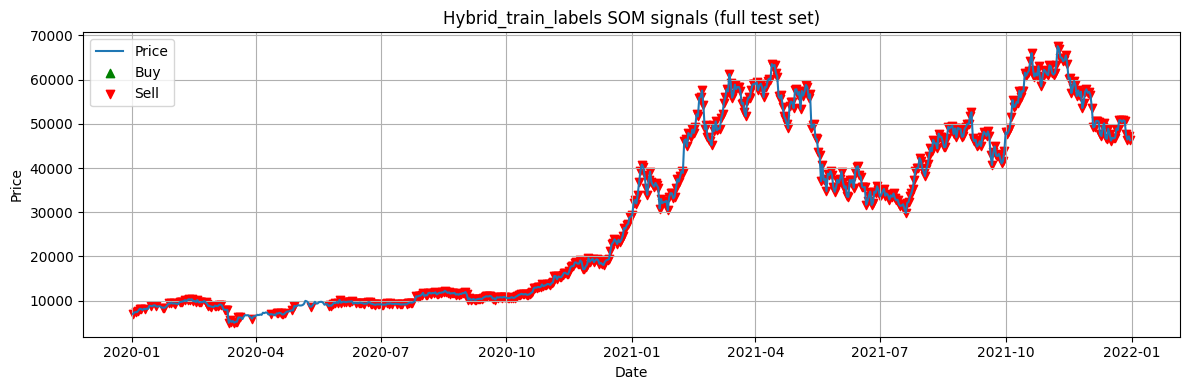

In [14]:
_, node_action_hybrid_train = process_and_signal(
    train_df,     # train set
    val_df,     
    som_hybrid,         
    feature_cols=best_features_map["hybrid"],
    model_name="hybrid_train_labels",
    save_dir="models"
)

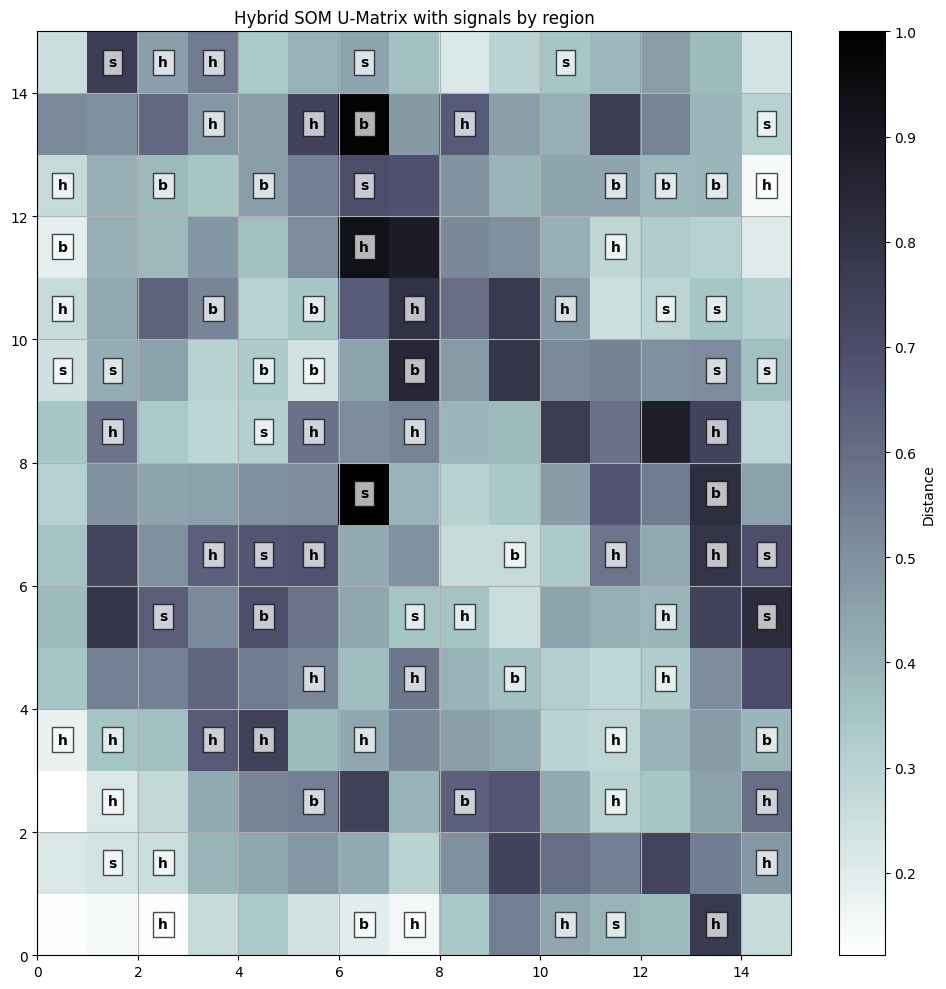

In [15]:
import matplotlib.pyplot as plt
import numpy as np

# Obter o mapa de distâncias (U-Matrix)
u_matrix = som_hybrid.distance_map().T  # transpor para que (x,y) fiquem corretos

plt.figure(figsize=(10, 10))
plt.pcolor(u_matrix, cmap='bone_r')
plt.colorbar(label='Distance')
plt.title("Hybrid SOM U-Matrix with signals by region")

# Adicionar texto nas células com o sinal atribuído ao BMU
for key, signal in node_action_hybrid_train.items():
    x, y = map(int, key.split('_'))
    plt.text(x + 0.5, y + 0.5, signal[0],  # Apenas a primeira letra: B, H, S
             ha='center', va='center',
             bbox=dict(facecolor='white', alpha=0.7),
             fontsize=10, fontweight='bold')


plt.grid(True)
plt.tight_layout()
plt.show()


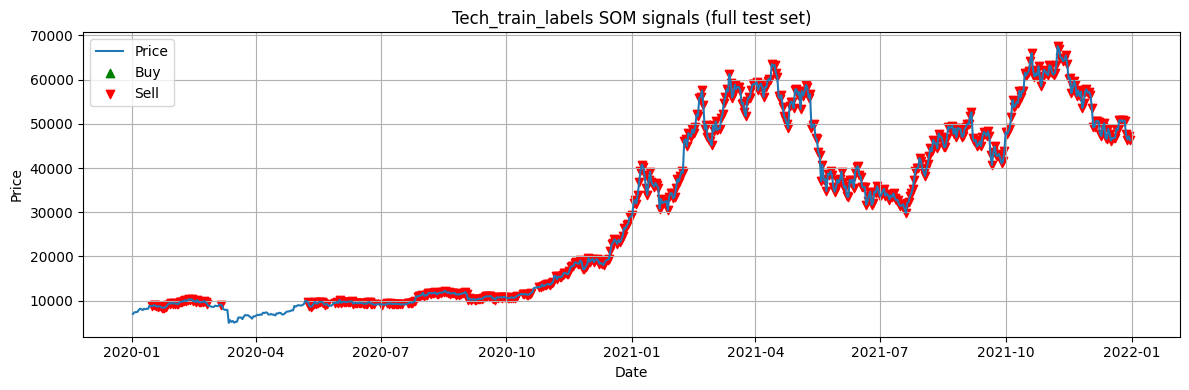

In [11]:

_, node_action_tech_train = process_and_signal(
    train_df,     # train set
    val_df,     
    som_tech,         
    feature_cols=best_features_map["technical"],
    model_name="tech_train_labels",
    save_dir="models"
)


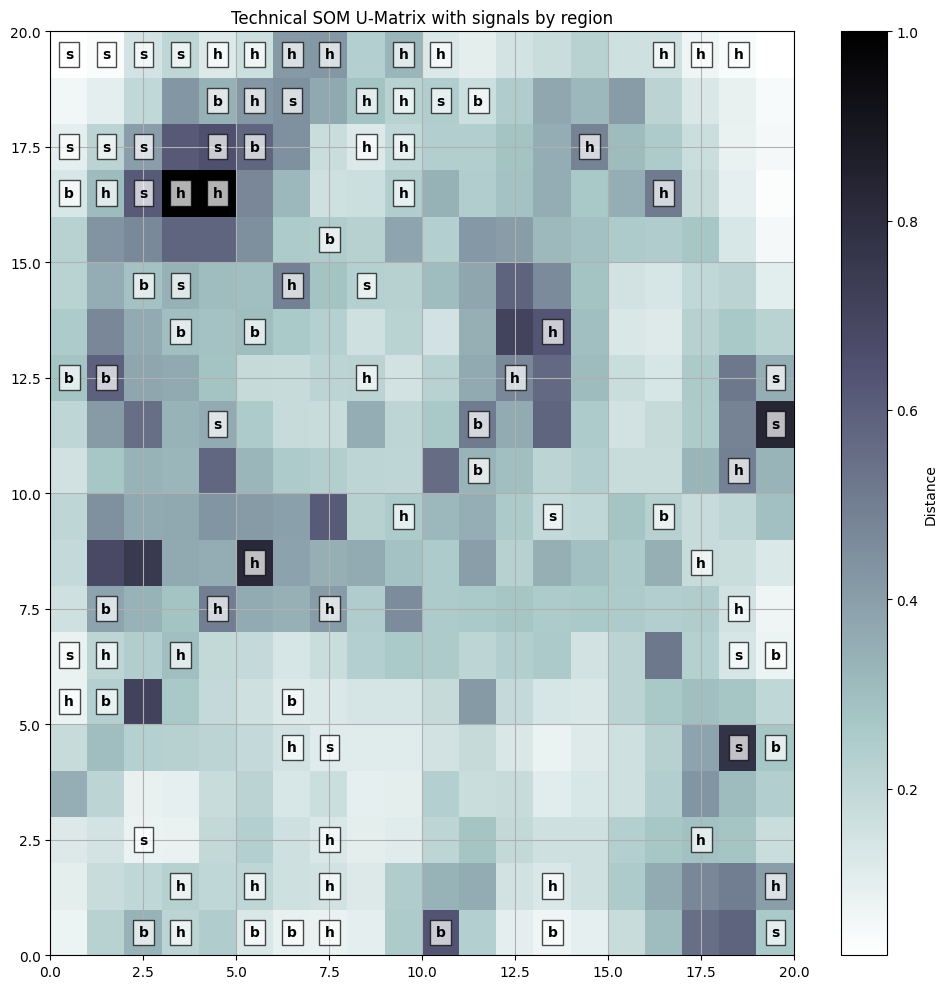

In [13]:
import matplotlib.pyplot as plt
import numpy as np

# Obter o mapa de distâncias (U-Matrix)
u_matrix = som_tech.distance_map().T  # transpor para que (x,y) fiquem corretos

plt.figure(figsize=(10, 10))
plt.pcolor(u_matrix, cmap='bone_r')
plt.colorbar(label='Distance')
plt.title("Technical SOM U-Matrix with signals by region")

# Adicionar texto nas células com o sinal atribuído ao BMU
for key, signal in node_action_tech_train.items():
    x, y = map(int, key.split('_'))
    plt.text(x + 0.5, y + 0.5, signal[0],  # Apenas a primeira letra: B, H, S
             ha='center', va='center',
             bbox=dict(facecolor='white', alpha=0.7),
             fontsize=10, fontweight='bold')


plt.grid(True)
plt.tight_layout()
plt.show()


## Correlation Between Trading Signals from SOM Models and Ensemble Strategies

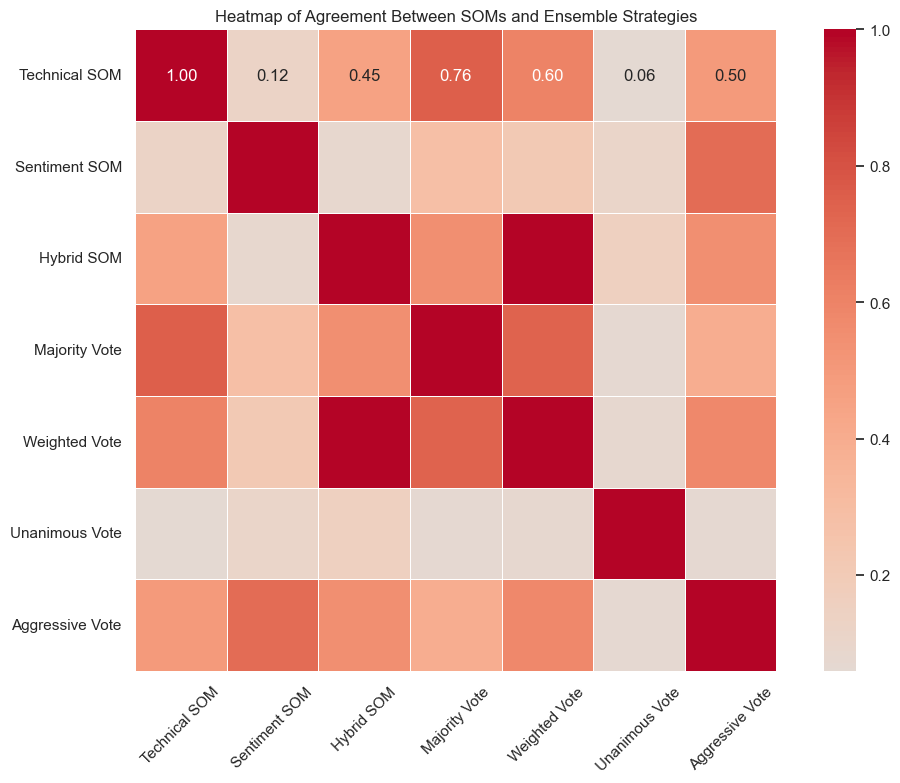

In [67]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Prepara os sinais
signals_df = pd.DataFrame({
    'Technical SOM': df_signals['signal_tech'],
    'Sentiment SOM': df_signals['signal_sent'],
    'Hybrid SOM': df_signals['signal_hybrid'],
    'Majority Vote': df_signals['ensemble_signal'],
    'Weighted Vote': df_signals['ensemble_weighted'],
    'Unanimous Vote': df_signals['ensemble_unanimous'],
    'Aggressive Vote': df_signals['ensemble_aggressive'],
})

# Converter sinais categóricos em valores numéricos
signal_map = {'buy': 1, 'hold': 0, 'sell': -1}
signals_numeric = signals_df.replace(signal_map).astype(float)

# Matriz de correlação
correlation_matrix = signals_numeric.corr()

# Heatmap com labels visíveis
plt.figure(figsize=(10, 8))

sns.heatmap(correlation_matrix, 
            annot=True,        # mostra os valores
            fmt=".2f",         # formatação: 2 casas decimais
            cmap="coolwarm",
            center=0, 
            linewidths=0.5,    # linhas divisórias mais visíveis
            cbar=True,         # barra de cor à direita
            square=True        # células quadradas
           )
plt.title("Heatmap of Agreement Between SOMs and Ensemble Strategies")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.subplots_adjust(bottom=0.25)
plt.tight_layout()
#plt.savefig("heatmap_test.png", dpi=300)
plt.show()



## statistical significance testing of daily returns

In [19]:
from scipy.stats import ttest_rel, wilcoxon
import pandas as pd

def compare_returns_statistically(results_dict):
    """
    Compare strategy returns using paired t-test and Wilcoxon signed-rank test.
    
    Args:
        results_dict: dict with strategy name as key and result DataFrame (with 'strategy_returns') as value.
    
    Returns:
        pd.DataFrame with p-values for t-test and Wilcoxon test for each pair.
    """
    strategies = list(results_dict.keys())
    pvals = []

    for i in range(len(strategies)):
        for j in range(i + 1, len(strategies)):
            name_i, name_j = strategies[i], strategies[j]
            df_i, df_j = results_dict[name_i], results_dict[name_j]

            # Align on index (date)
            common = df_i[['strategy_returns']].join(df_j[['strategy_returns']], lsuffix='_i', rsuffix='_j').dropna()

            if len(common) < 10:
                continue  # not enough overlap

            # Paired t-test
            t_stat, t_p = ttest_rel(common['strategy_returns_i'], common['strategy_returns_j'])
            
            # Wilcoxon test (non-parametric)
            try:
                w_stat, w_p = wilcoxon(common['strategy_returns_i'], common['strategy_returns_j'])
            except ValueError:
                w_p = float('nan')  # Not enough differences

            pvals.append({
                'Strategy A': name_i,
                'Strategy B': name_j,
                't-test p-value': t_p,
                'Wilcoxon p-value': w_p
            })

    return pd.DataFrame(pvals)


In [20]:
strategies = {
    'Tech SOM': result_tech,
    'Sentiment SOM': result_sent,
    'Hybrid SOM': result_hybrid,
    'Fear & Greed': result_fg,
    'Ensemble Majority': result_ens_majority,
    'Ensemble Weighted': result_ens_weighted,
    'Ensemble Unanimous': result_ens_unanimous
}


In [28]:
stats_df = compare_returns_statistically(strategies)

from IPython.display import display

display(stats_df)


,Strategy A,Strategy B,t-test p-value,Wilcoxon p-value
0,Tech SOM,Sentiment SOM,0.420031,0.902605
1,Tech SOM,Hybrid SOM,0.108174,0.157391
2,Tech SOM,Fear & Greed,0.467186,0.251352
3,Tech SOM,Ensemble Majority,0.273744,0.143848
4,Tech SOM,Ensemble Weighted,0.353049,0.492957
5,Tech SOM,Ensemble Unanimous,0.060296,0.123338
6,Sentiment SOM,Hybrid SOM,0.461479,0.126123
7,Sentiment SOM,Fear & Greed,0.999732,0.192683
8,Sentiment SOM,Ensemble Majority,0.950952,0.242861
9,Sentiment SOM,Ensemble Weighted,0.878575,0.720826


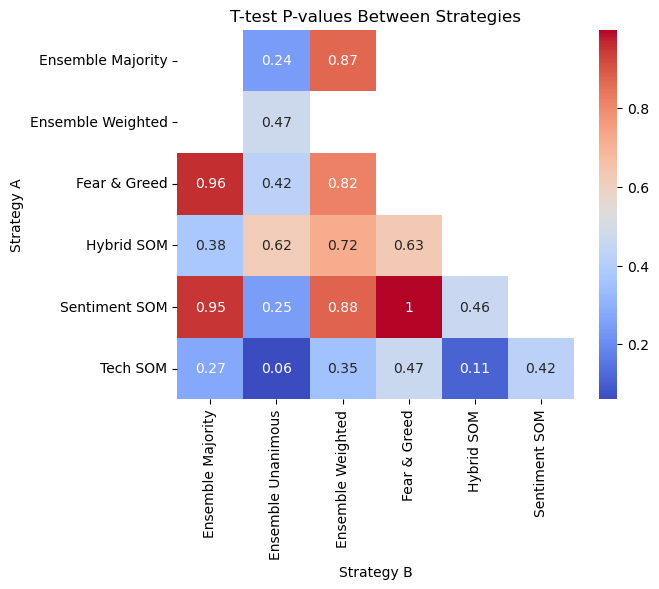

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

pivot = stats_df.pivot(index='Strategy A', columns='Strategy B', values='t-test p-value')
sns.heatmap(pivot, annot=True, cmap='coolwarm')
plt.title("T-test P-values Between Strategies")
plt.show()
